In [4]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv("dataset.csv")

# 创建均价列
df['均价'] = df['价格'] / df['总面积']

# 查看数据
print(df.head())      # 查看前5行（Python 默认是5行）
print("\n数据类型：")
print(df.dtypes)      # 查看数据结构
print("\n统计摘要：")
print(df.describe(include='all'))  # 查看统计摘要

# 如果需要更详细的统计信息（类似 R 的 summary）
print("\n详细统计摘要：")
print(df.info())      # 查看数据框信息
print("\n")
print(df.describe())  # 数值列的统计信息

                               标题  居室数  厅堂数  卫生间数  总面积    建造年份  居民楼总层数  \
0  扫码唻电联系房东，真的急疯了，这价格还卖不掉房东说要刀了我！    2    1     1   17  2018.0    11.0   
1             正南 3室2厅 万科海上传奇(一二期)    3    2     1   97  2014.0    22.0   
2                虹浦新城南区 通透三房 预约看房    3    1     1   93  2007.0    11.0   
3     18号地铁口！进才  ，南北通透沉香苑，房东置换急 售    2    2     1   90  2013.0    11.0   
4  市区独栋别墅！送400平大花园！自带私家游泳池！位置不靠马路    5    3     3  300  2010.0     2.0   

     小区户数  小区绿化率  物业费用  ...           小区      南     南北   近地铁   车位充足   户型方正  \
0    50.0   30.0  0.40  ...      虹中路2弄小区  False   True  True   True  False   
1  2336.0   45.0  3.00  ...  万科海上传奇(一二期)   True  False  True  False  False   
2  1731.0   30.0  1.25  ...     虹浦新城(南区)  False   True  True  False  False   
3   971.0   35.0  1.20  ...       沉香苑一街坊  False   True  True  False   True   
4    68.0   43.0  5.50  ...         虹梅别墅   True  False  True   True  False   

    多人关注    有电梯    价格         均价  
0  False  False    50   2.941176  
1  False  False 

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

# ==================== macOS 中文显示终极设置 ====================

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


def plot_boxplot_single(df, var, order=None):
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    # 1. 确定分组顺序
    if order is not None:
        order = [cat for cat in order if cat in df[var].unique()]
    else:
        order = sorted(df[var].unique().tolist())  
    
    # 2. 计算样本量 → 宽度与样本量成正比
    counts = df[var].value_counts().reindex(order, fill_value=0)
    max_count = counts.max()  # 最大频数
    if max_count == 0:
        widths = np.full(len(counts), 0.05)
    else:
        widths = (counts / max_count) * 0.95  # 按最大组比例计算
    widths = np.clip(widths, 0.05, 0.95)

    # 3. 数据分组
    positions = np.arange(len(order))  # 固定位置 → 箱体间距完全相等
    data_groups = [df[df[var] == cat]['均价'].values for cat in order]

    plt.figure(figsize=(12, 6))

    # 4. 绘制箱线图（间距相等 + 各自宽度不同）
    bp = plt.boxplot(
        data_groups,
        positions=positions,
        widths=widths,
        patch_artist=True,
        showfliers=True,  # 显示离群点
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'linewidth': 1.2},
        capprops={'linewidth': 1.2},
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}  # 离群点变小、透明
    )

    # 配色
    colors = sns.color_palette("Set2", len(order))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)

    # ==================== 核心改进：限制Y轴，让箱体正常显示 ====================
    upper_bound = np.percentile(df['均价'].dropna(), 99)
    plt.ylim(0, upper_bound * 1.1)  

    # ==================== 核心改进：固定间距，等间距排列 ====================
    plt.xticks(positions, order, rotation=45, ha='right',fontsize=14, fontweight='bold' )
    plt.yticks(fontsize=14)
    plt.xlim(-0.5, len(order)-0.5)

    # 样式
    #plt.title(f'均价按 {var} 分组（宽度∝样本量｜y轴以99%分位数截断）', fontsize=14, fontweight='bold')
    plt.xlabel(var, fontsize=14)
    plt.ylabel('均价（万元/平米）以99%分位数截断', fontsize=14)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()

    # 保存
    plt.savefig(f'boxplot_{var}.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    # 统计
    print(f"\n【{var} 统计】")
    stats = df.groupby(var)['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
    print(stats)

    print("\n箱体宽度：")
    for cat, cnt, w in zip(order, counts, widths):
        print(f"  {cat}: 样本量={cnt}, 宽度={w:.2f}")

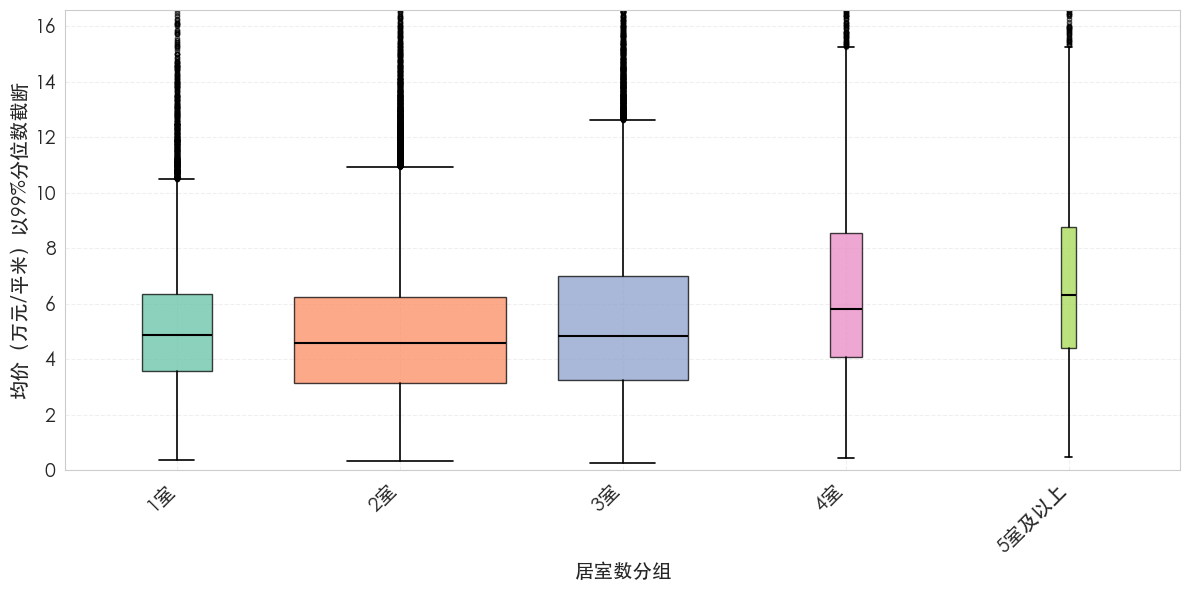


【居室数分组 统计】
       count  mean  median   std
居室数分组                           
1室     26562  5.24    4.88  2.49
2室     80884  4.96    4.60  2.52
3室     49656  5.47    4.84  3.06
4室     12226  6.74    5.81  3.99
5室及以上   5799  7.33    6.32  4.69

箱体宽度：
  1室: 样本量=26562, 宽度=0.31
  2室: 样本量=80884, 宽度=0.95
  3室: 样本量=49656, 宽度=0.58
  4室: 样本量=12226, 宽度=0.14
  5室及以上: 样本量=5799, 宽度=0.07


In [59]:
df = df[df['居室数'] != 0].copy()
df['居室数分组'] = df['居室数'].apply(lambda x: '5室及以上' if x > 4 else str(x) + '室')
plot_boxplot_single(df, '居室数分组',order=['1室', '2室', '3室', '4室', '5室及以上'])

In [61]:

df['厅堂数分组'] = df['厅堂数'].apply(lambda x: '3厅及以上' if x > 2 else str(x) + '厅')
stats = df.groupby('厅堂数分组')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

        count  mean  median   std
厅堂数分组                            
0厅       4096  5.92    5.58  2.60
1厅      61283  4.88    4.74  2.14
2厅     104362  5.52    4.81  3.22
3厅及以上    5386  6.90    6.05  4.30


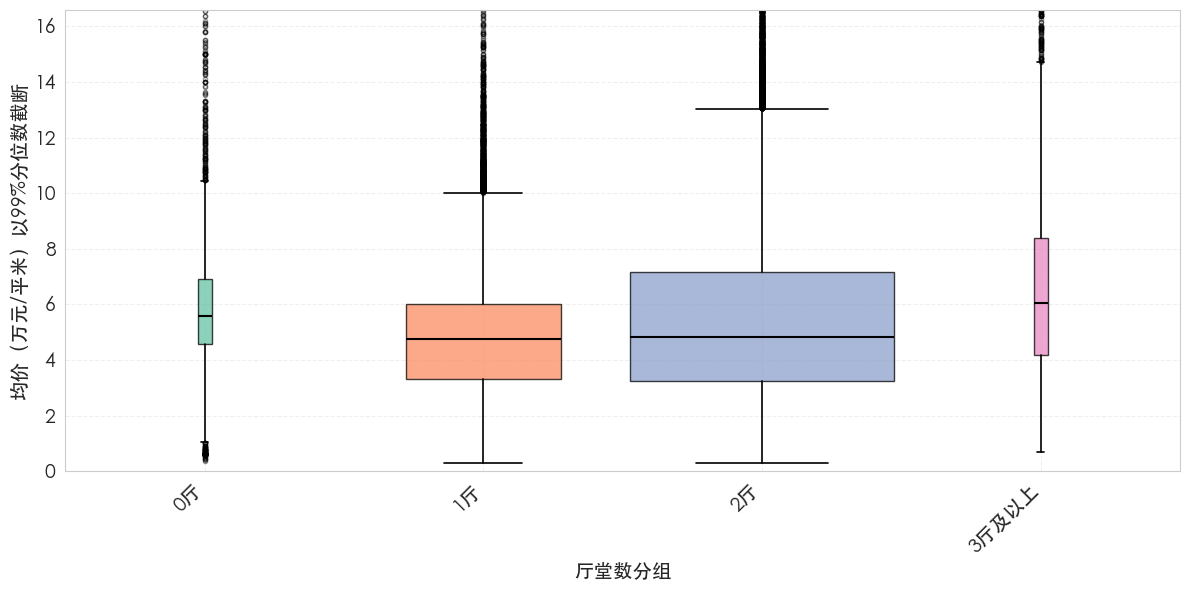


【厅堂数分组 统计】
        count  mean  median   std
厅堂数分组                            
0厅       4096  5.92    5.58  2.60
1厅      61283  4.88    4.74  2.14
2厅     104362  5.52    4.81  3.22
3厅及以上    5386  6.90    6.05  4.30

箱体宽度：
  0厅: 样本量=4096, 宽度=0.05
  1厅: 样本量=61283, 宽度=0.56
  2厅: 样本量=104362, 宽度=0.95
  3厅及以上: 样本量=5386, 宽度=0.05


In [62]:
plot_boxplot_single(df, '厅堂数分组',order=['0厅', '1厅', '2厅', '3厅及以上'])

In [64]:
df['卫生间数分组'] = df['卫生间数'].apply(lambda x: '0-1卫' if x < 2 else ('2卫' if x == 2 else '3卫及以上'))
stats = df.groupby('卫生间数分组')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

         count  mean  median   std
卫生间数分组                            
0-1卫    121849  4.88    4.58  2.37
2卫       39378  6.16    5.60  3.34
3卫及以上    13900  7.17    6.02  4.64


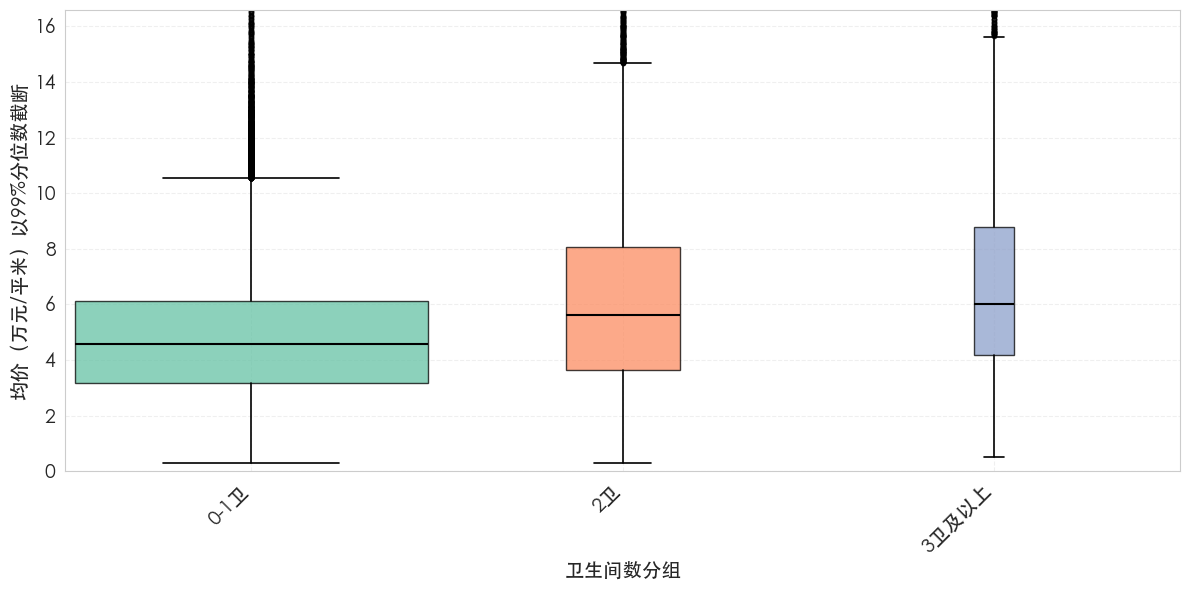


【卫生间数分组 统计】
         count  mean  median   std
卫生间数分组                            
0-1卫    121849  4.88    4.58  2.37
2卫       39378  6.16    5.60  3.34
3卫及以上    13900  7.17    6.02  4.64

箱体宽度：
  0-1卫: 样本量=121849, 宽度=0.95
  2卫: 样本量=39378, 宽度=0.31
  3卫及以上: 样本量=13900, 宽度=0.11


In [66]:
plot_boxplot_single(df, '卫生间数分组',order=['0-1卫', '2卫', '3卫及以上'])

In [70]:
df['房龄分组'] = df['建造年份'].apply(
    lambda x: 
    '未知' if (2026 - x) < 0 else
    '3年以内' if (2026 - x) <= 3 else
    '3-10年' if (2026- x) <= 10 else
    '10-20年' if (2026 - x) <= 20 else
    '20-30年' if (2026 - x) <= 30 else
    '30年以上'
)
stats = df.groupby('房龄分组')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

        count  mean  median   std
房龄分组                             
10-20年  63297  4.94    4.16  2.95
20-30年  54693  5.97    5.64  2.56
3-10年   28799  4.74    3.62  3.71
30年以上   25910  5.67    5.40  2.34
3年以内     2428  5.91    4.76  3.51


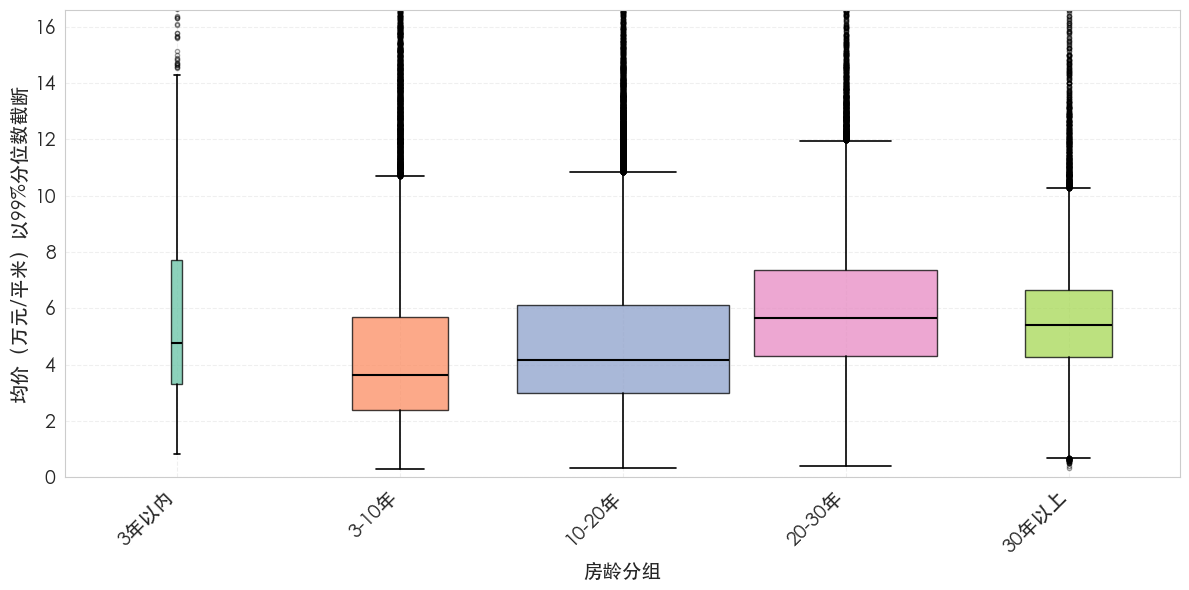


【房龄分组 统计】
        count  mean  median   std
房龄分组                             
10-20年  63297  4.94    4.16  2.95
20-30年  54693  5.97    5.64  2.56
3-10年   28799  4.74    3.62  3.71
30年以上   25910  5.67    5.40  2.34
3年以内     2428  5.91    4.76  3.51

箱体宽度：
  3年以内: 样本量=2428, 宽度=0.05
  3-10年: 样本量=28799, 宽度=0.43
  10-20年: 样本量=63297, 宽度=0.95
  20-30年: 样本量=54693, 宽度=0.82
  30年以上: 样本量=25910, 宽度=0.39


In [71]:
plot_boxplot_single(df, '房龄分组',order=['3年以内', '3-10年', '10-20年','20-30年', '30年以上'])

In [74]:
df['朝向'] = df['南北'].apply(
    lambda x: 
    '南北' if x == True else
    '非南北'
)
stats = df.groupby('朝向')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

      count  mean  median   std
朝向                             
南北   109123  5.26    4.76  2.88
非南北   66004  5.49    4.99  3.05


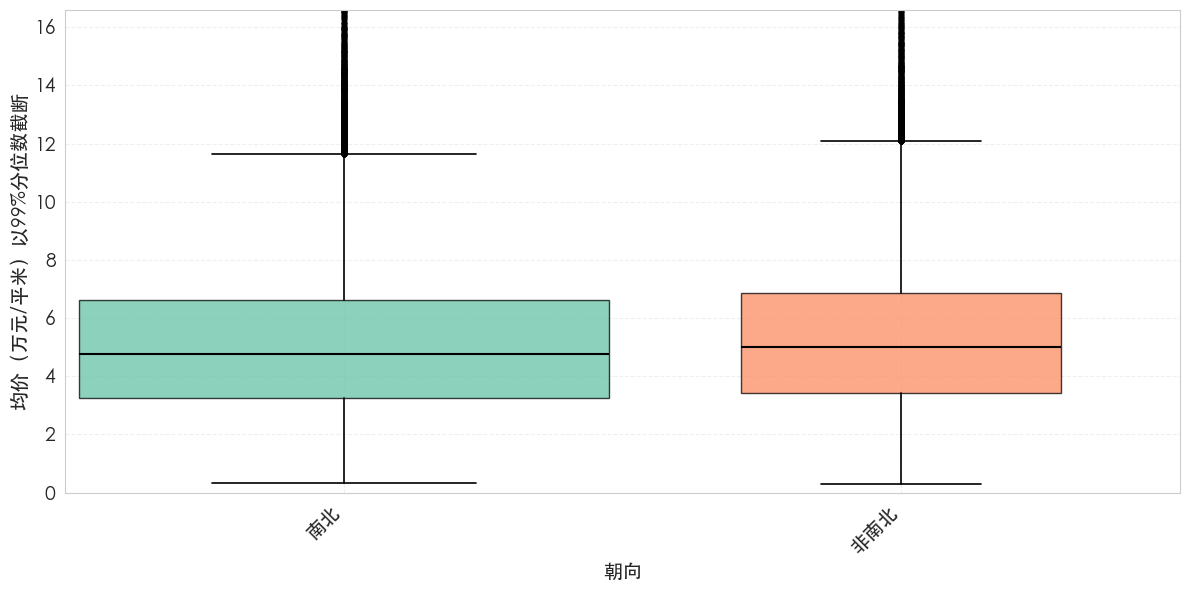


【朝向 统计】
      count  mean  median   std
朝向                             
南北   109123  5.26    4.76  2.88
非南北   66004  5.49    4.99  3.05

箱体宽度：
  南北: 样本量=109123, 宽度=0.95
  非南北: 样本量=66004, 宽度=0.57


In [75]:
plot_boxplot_single(df, '朝向',order=['南北', '非南北'])

In [77]:
df['是否近地铁'] = df['近地铁'].apply(
    lambda x: 
    '是' if x == True else
    '否'
)
stats = df.groupby('是否近地铁')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

        count  mean  median   std
是否近地铁                            
否       55505  3.67    3.13  2.24
是      119622  6.13    5.53  2.91


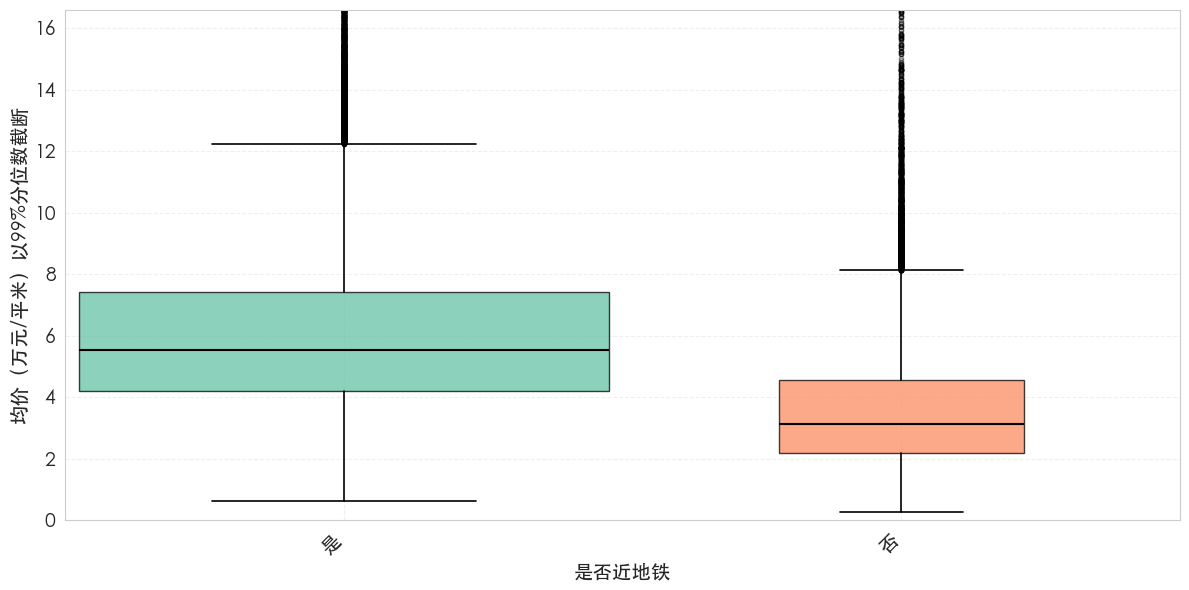


【是否近地铁 统计】
        count  mean  median   std
是否近地铁                            
否       55505  3.67    3.13  2.24
是      119622  6.13    5.53  2.91

箱体宽度：
  是: 样本量=119622, 宽度=0.95
  否: 样本量=55505, 宽度=0.44


In [78]:
plot_boxplot_single(df, '是否近地铁',order=['是', '否'])

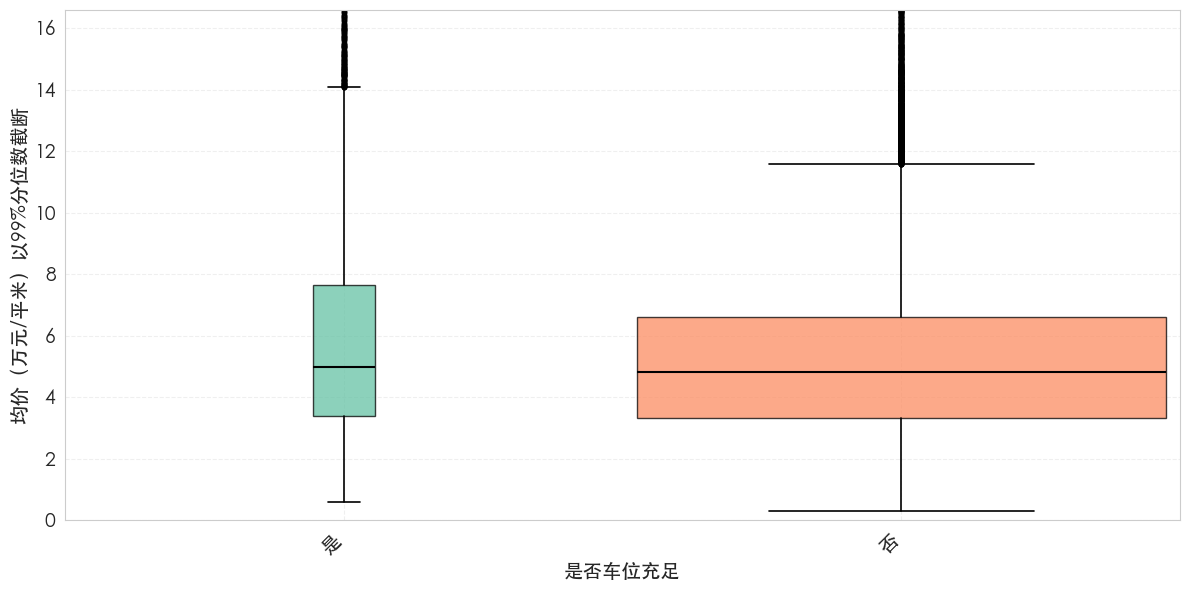


【是否车位充足 统计】
         count  mean  median   std
是否车位充足                            
否       156642  5.26    4.83  2.79
是        18485  6.10    4.99  3.99

箱体宽度：
  是: 样本量=18485, 宽度=0.11
  否: 样本量=156642, 宽度=0.95


In [79]:
df['是否车位充足'] = df['车位充足'].apply(
    lambda x: 
    '是' if x == True else
    '否'
)
plot_boxplot_single(df, '是否车位充足',order=['是', '否'])

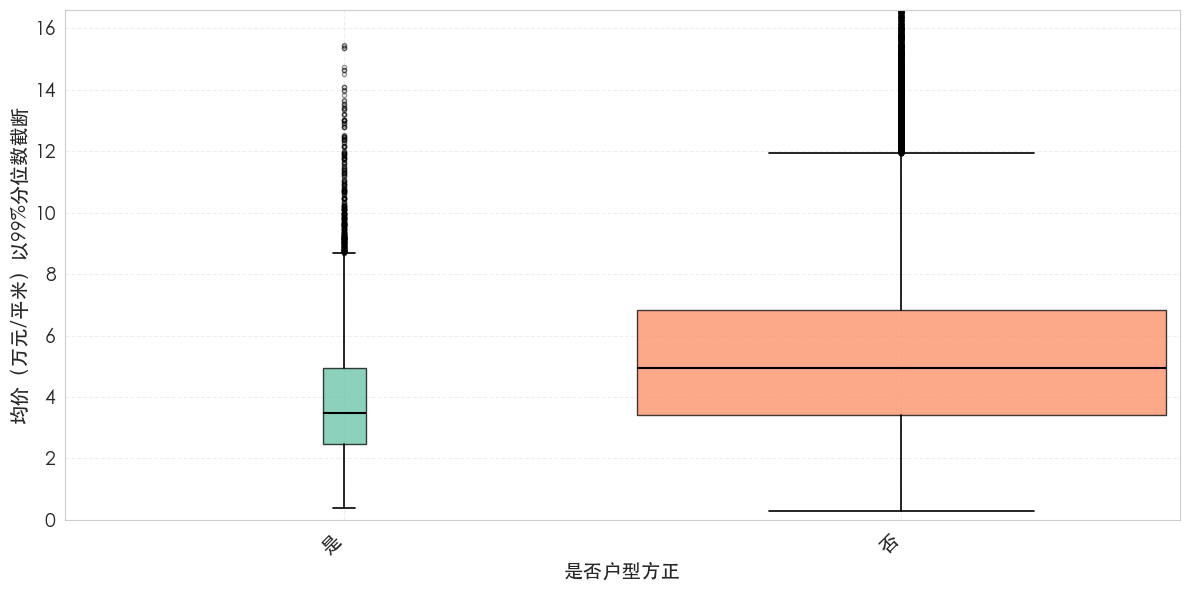


【是否户型方正 统计】
         count  mean  median   std
是否户型方正                            
否       161979  5.46    4.95  2.98
是        13148  3.93    3.48  2.03

箱体宽度：
  是: 样本量=13148, 宽度=0.08
  否: 样本量=161979, 宽度=0.95


In [80]:
df['是否户型方正'] = df['户型方正'].apply(
    lambda x: 
    '是' if x == True else
    '否'
)
plot_boxplot_single(df, '是否户型方正',order=['是', '否'])

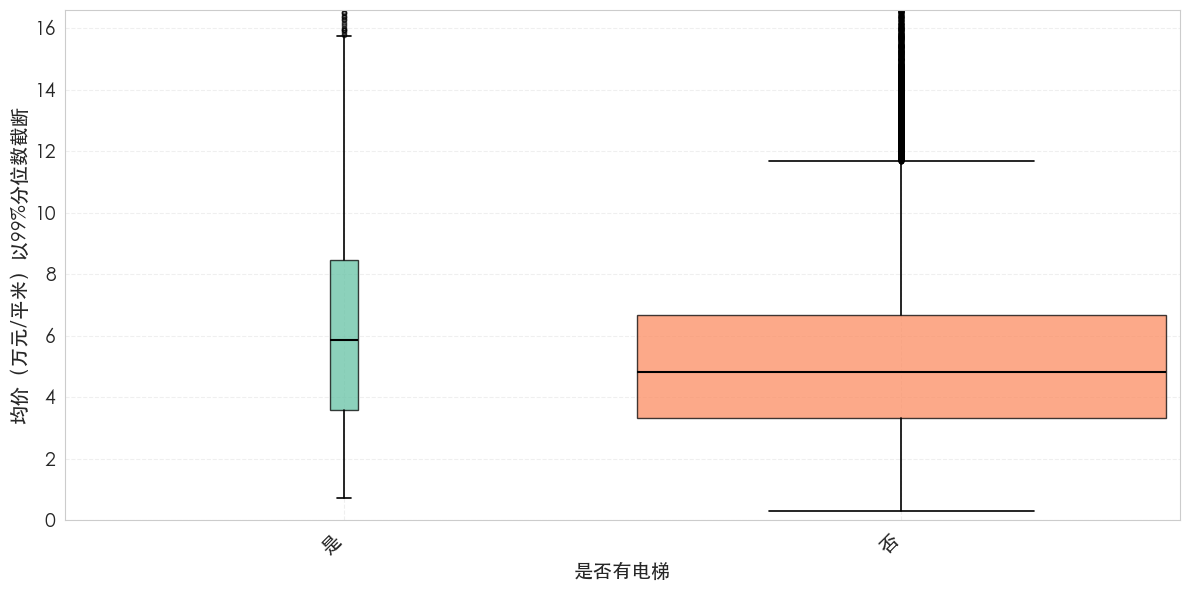


【是否有电梯 统计】
        count  mean  median  std
是否有电梯                           
否      170048  5.31    4.82  2.9
是        5079  6.66    5.86  4.1

箱体宽度：
  是: 样本量=5079, 宽度=0.05
  否: 样本量=170048, 宽度=0.95


In [81]:
df['是否有电梯'] = df['有电梯'].apply(
    lambda x: 
    '是' if x == True else
    '否'
)
plot_boxplot_single(df, '是否有电梯',order=['是', '否'])

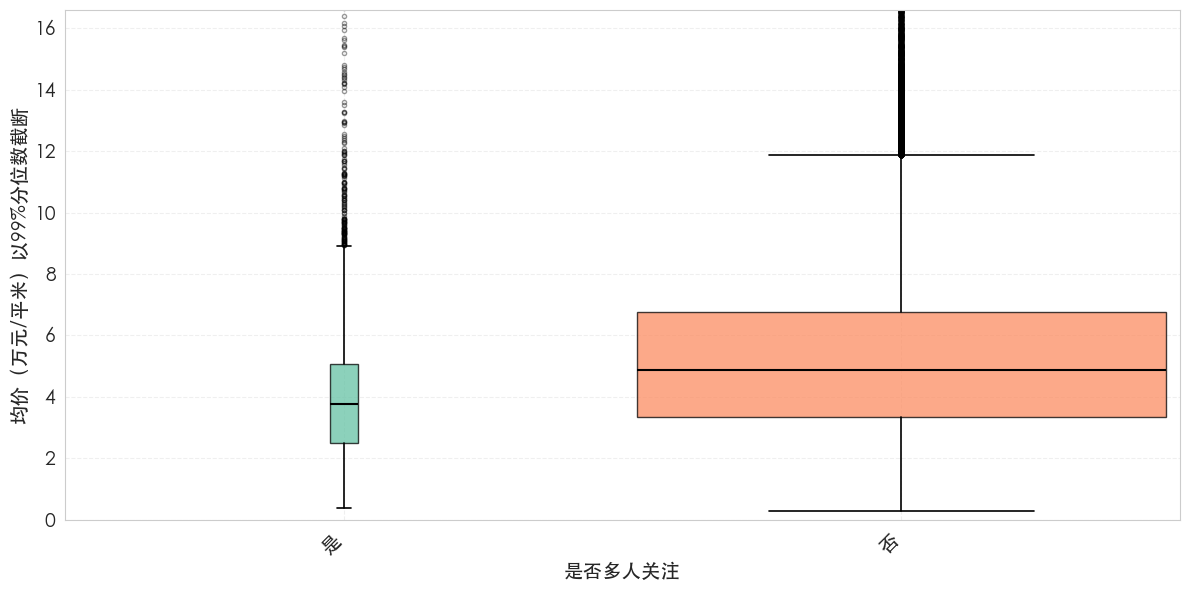


【是否多人关注 统计】
         count  mean  median   std
是否多人关注                            
否       169057  5.39    4.88  2.95
是         6070  4.14    3.77  2.65

箱体宽度：
  是: 样本量=6070, 宽度=0.05
  否: 样本量=169057, 宽度=0.95


In [82]:
df['是否多人关注'] = df['多人关注'].apply(
    lambda x: 
    '是' if x == True else
    '否'
)
plot_boxplot_single(df, '是否多人关注',order=['是', '否'])

In [85]:
df['总楼层数分组'] = df['居民楼总层数'].apply(
    lambda x: 
    '3层及以下' if x <= 3 else
    '3-6层' if x <= 6 else
    '6-12层' if x <= 12 else
    '12-18层' if x <= 18 else
    '18-32层' if x <= 32 else
    '32层以上'
)
stats = df.groupby('总楼层数分组')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

        count  mean  median   std
总楼层数分组                           
12-18层  40733  4.87    4.18  2.65
18-32层  22816  7.11    6.65  3.77
3-6层    72720  4.76    4.67  2.07
32层以上    3782  9.49    9.51  4.11
3层及以下    8966  6.53    5.72  4.22
6-12层   26110  5.19    4.77  2.73


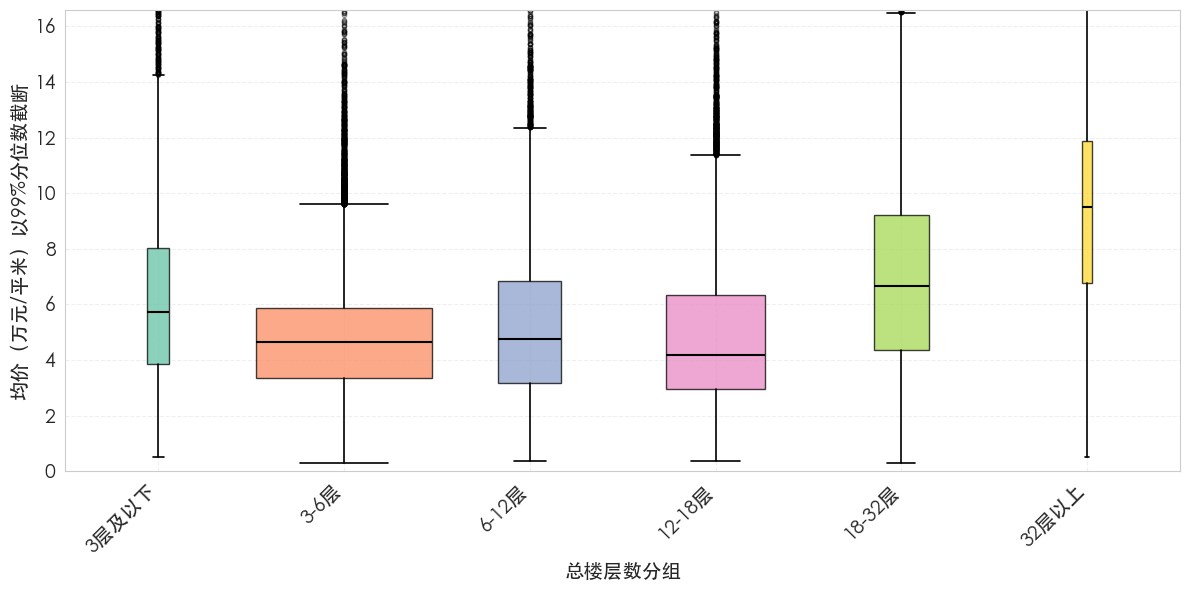


【总楼层数分组 统计】
        count  mean  median   std
总楼层数分组                           
12-18层  40733  4.87    4.18  2.65
18-32层  22816  7.11    6.65  3.77
3-6层    72720  4.76    4.67  2.07
32层以上    3782  9.49    9.51  4.11
3层及以下    8966  6.53    5.72  4.22
6-12层   26110  5.19    4.77  2.73

箱体宽度：
  3层及以下: 样本量=8966, 宽度=0.12
  3-6层: 样本量=72720, 宽度=0.95
  6-12层: 样本量=26110, 宽度=0.34
  12-18层: 样本量=40733, 宽度=0.53
  18-32层: 样本量=22816, 宽度=0.30
  32层以上: 样本量=3782, 宽度=0.05


In [88]:
plot_boxplot_single(df, '总楼层数分组',order=['3层及以下', '3-6层', '6-12层', '12-18层', '18-32层', '32层以上'])

In [90]:
df['小区户数分组'] = df['小区户数'].apply(
    lambda x: 
    '500户及以下' if x <= 500 else
    '500-1000户' if x <= 1000 else
    '1000-2000户' if x <= 2000 else
    '2000户以上'
)
stats = df.groupby('小区户数分组')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

            count  mean  median   std
小区户数分组                               
1000-2000户  57751  5.01    4.53  2.61
2000户以上     30248  4.74    4.55  2.02
500-1000户   48476  5.43    4.83  3.11
500户及以下     38652  6.24    5.79  3.56


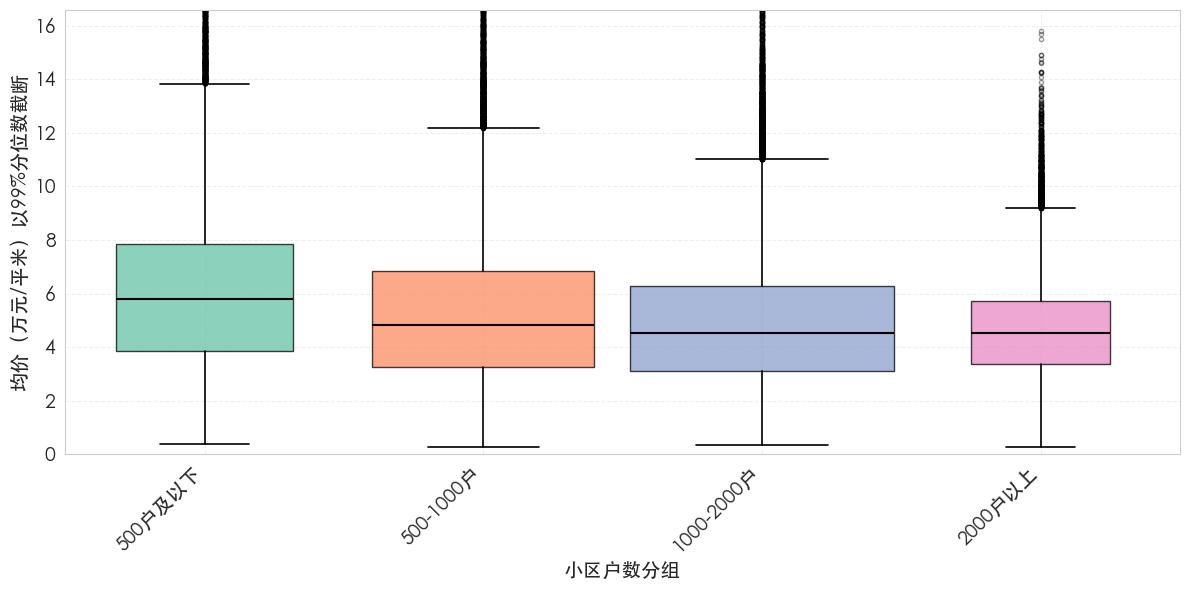


【小区户数分组 统计】
            count  mean  median   std
小区户数分组                               
1000-2000户  57751  5.01    4.53  2.61
2000户以上     30248  4.74    4.55  2.02
500-1000户   48476  5.43    4.83  3.11
500户及以下     38652  6.24    5.79  3.56

箱体宽度：
  500户及以下: 样本量=38652, 宽度=0.64
  500-1000户: 样本量=48476, 宽度=0.80
  1000-2000户: 样本量=57751, 宽度=0.95
  2000户以上: 样本量=30248, 宽度=0.50


In [92]:
plot_boxplot_single(df, '小区户数分组',order=['500户及以下', '500-1000户', '1000-2000户', '2000户以上'])

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==================== 全局中文配置 ====================
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 通用直方图函数 ====================
def plot_histogram(df, col_name, bins=20, clip_percent=99, kde=True):
    """
    通用数值变量直方图
    :param df: 数据集
    :param col_name: 变量名字符串，如 '面积','均价'
    :param bins: 分箱数
    :param clip_percent: 截断上分位数，过滤极端异常值
    :param kde: 是否显示核密度曲线
    """
    # 清洗数据：去空值
    data = df[col_name].dropna()
    
    # 过滤极端最大值，防止图形被挤压
    upper = np.percentile(data, clip_percent)
    data = data[data <= upper]

    plt.figure(figsize=(12, 7))
    
    sns.histplot(
        data=data,
        bins=bins,
        color='#66c2a5',
        alpha=0.75,
        kde=kde
    )

    # 标签、标题、刻度字体放大
    plt.xlabel(f'{col_name}', fontsize=16, fontweight='bold')
    plt.ylabel('房源数量', fontsize=16, fontweight='bold')
    #plt.title(f'{col_name} 分布直方图', fontsize=18, fontweight='bold')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # 保存图片
    plt.savefig(f'hist_{col_name}.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

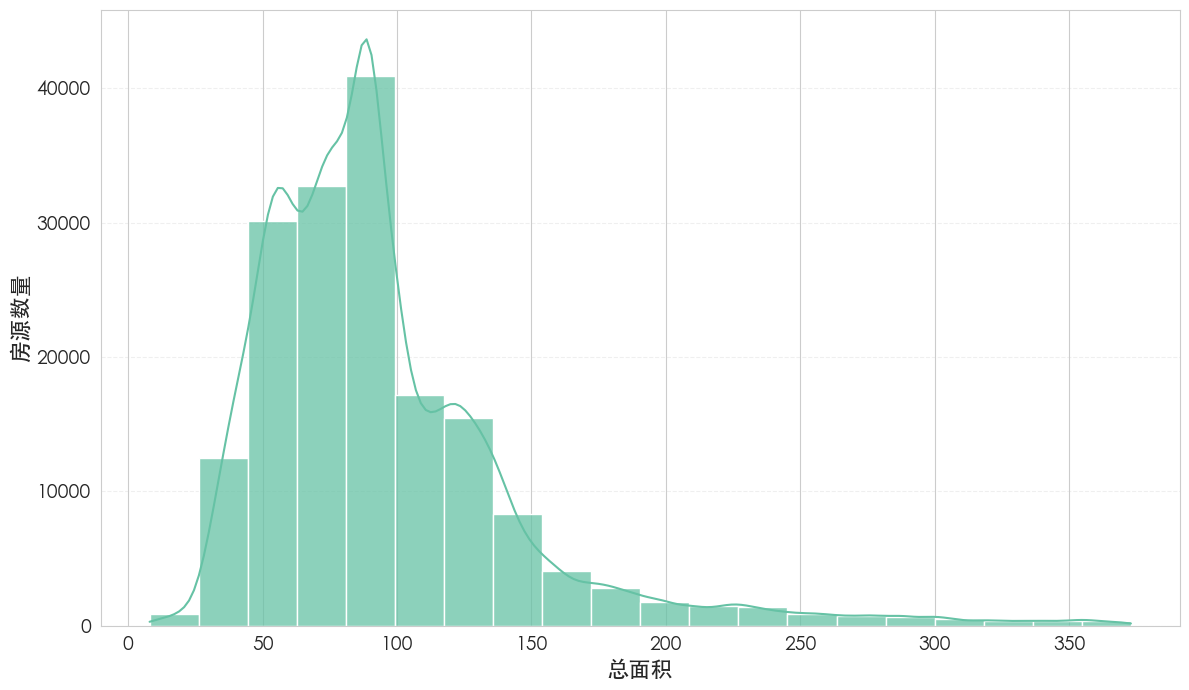

In [96]:
plot_histogram(df, "总面积")

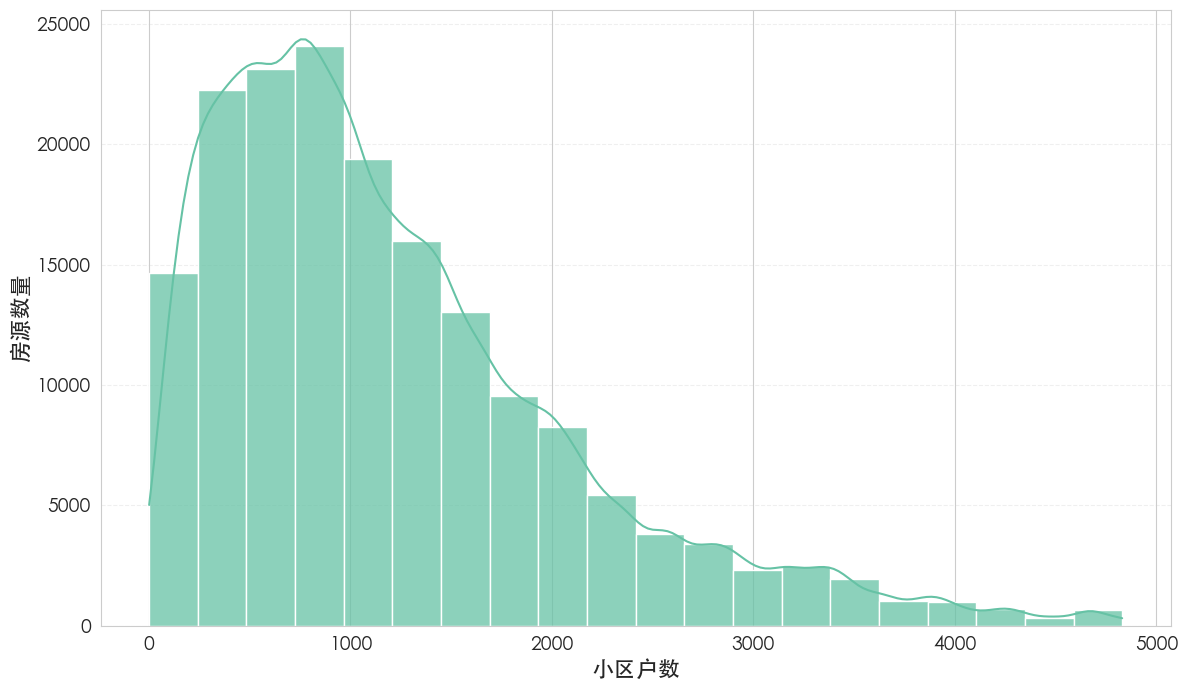

In [97]:
plot_histogram(df, "小区户数")

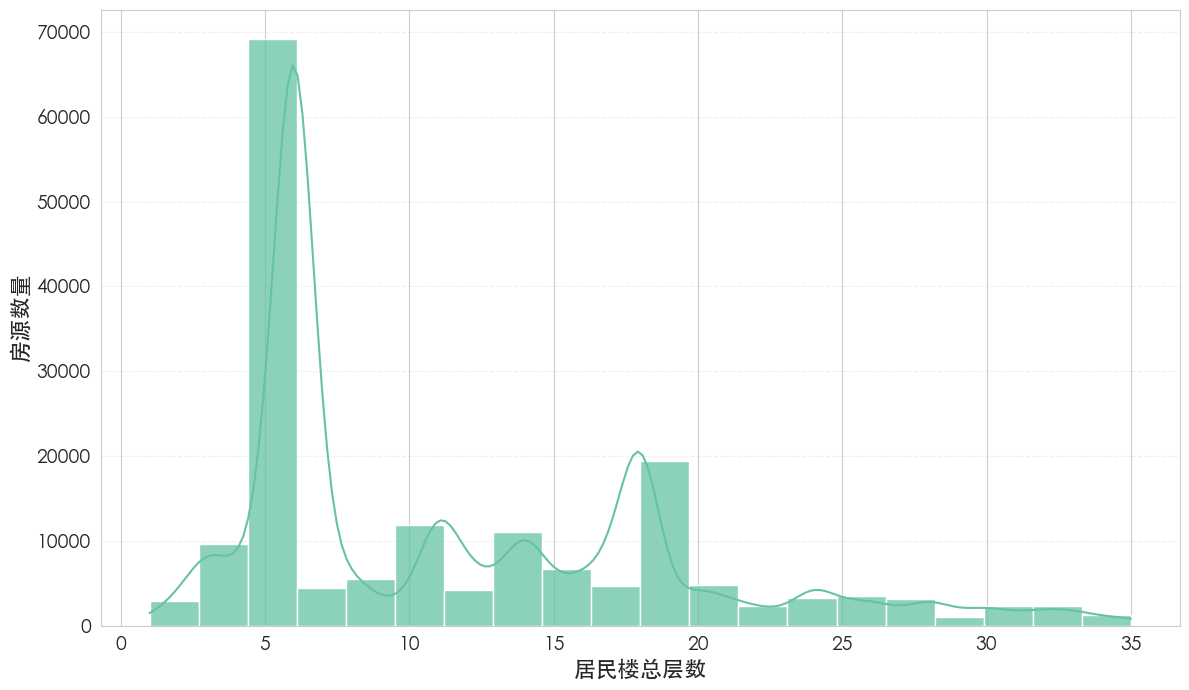

In [98]:
plot_histogram(df, "居民楼总层数")

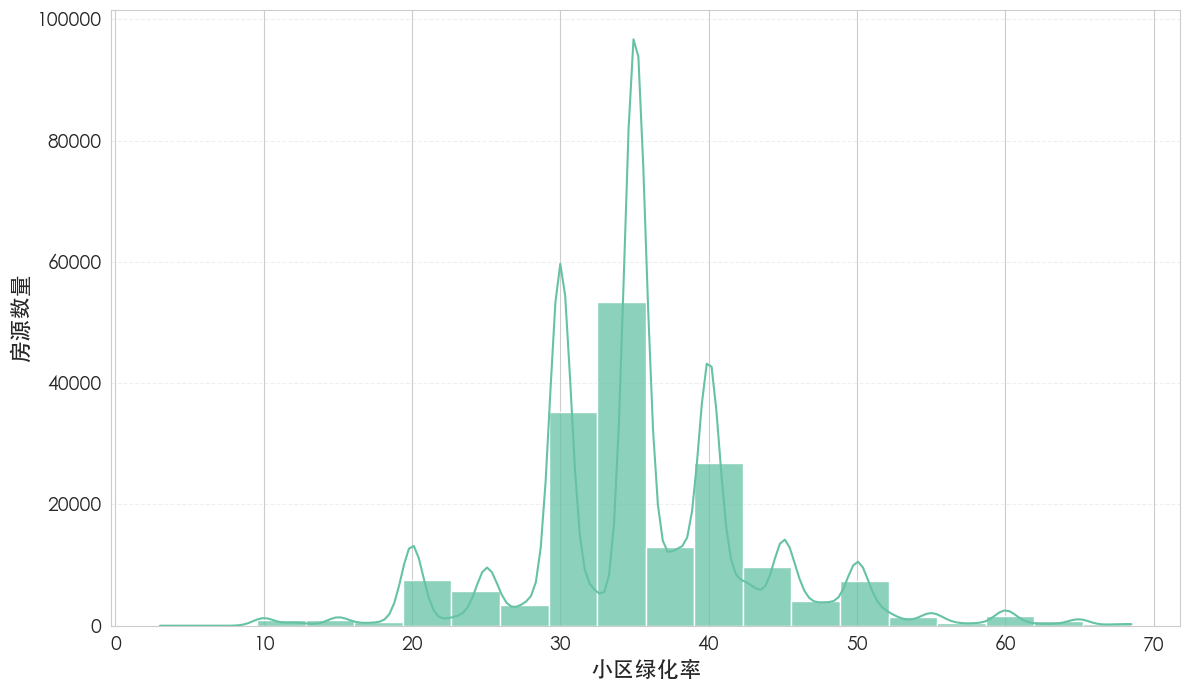

In [99]:
plot_histogram(df, "小区绿化率")

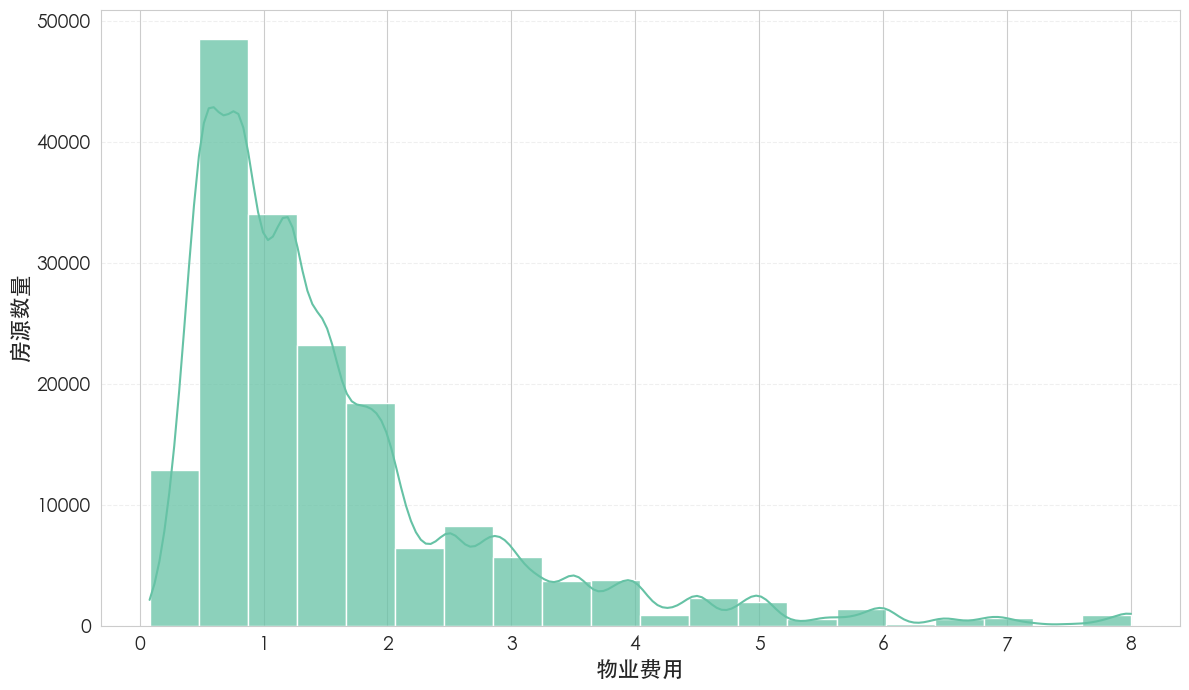

In [100]:
plot_histogram(df, "物业费用")

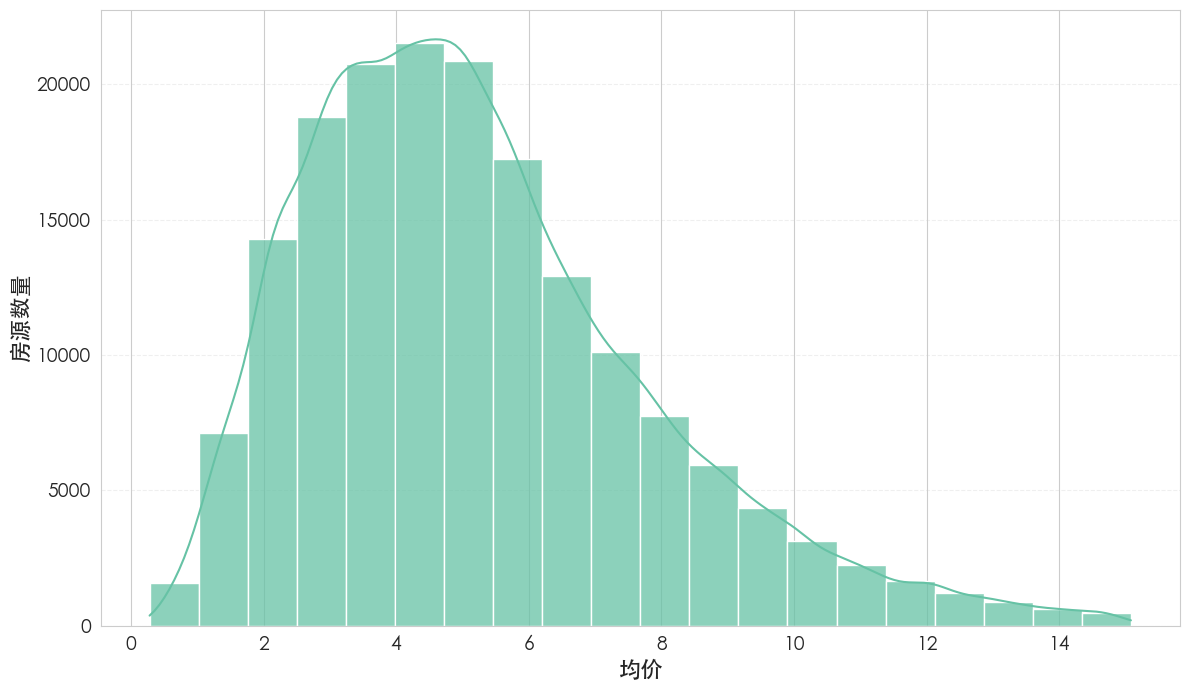

In [101]:
plot_histogram(df, "均价")

In [125]:
df['均价分组'] = df['均价'].apply(
    lambda x: 
    '3万及以下' if x <= 3 else
    '3-6万' if x <= 6 else
    '6万以上'
)

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==================== 中文全局配置 ====================
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 通用直方图函数 ====================
def plot_histogram_n(df, col_name, hue_col=None, bins=20, clip_percent=99):
    """
    :param df: 数据集
    :param col_name: 横轴数值变量名
    :param hue_col: 分组列名（这里传 均价分组）
    :param bins: 分箱数
    :param clip_percent: 截断上分位数，过滤极端值
    """
    data_series = df[col_name].dropna()
    upper = np.percentile(data_series, clip_percent)
    df_plot = df[(df[col_name] <= upper)].copy()

    plt.figure(figsize=(12, 7))

    # 固定 hue=均价分组，每张图都用这三组拆分
    sns.histplot(
        data=df_plot,
        x=col_name,
        hue="均价分组",
        bins=bins,
        kde=False,
        multiple="stack",  # 分段堆叠成一根柱子
        shrink=1,          # 柱子占满宽度
        palette=["#66c2a5", "#fc8d62", "#8da0cb"],
        edgecolor="white",
        linewidth=0.5,
        alpha=0.9
    )

    # 放大字体
    plt.xlabel(f"{col_name}", fontsize=16, fontweight="bold")
    plt.ylabel("房源数量", fontsize=16, fontweight="bold")
    #plt.title(f"{col_name} 分布（按均价分组）", fontsize=18, fontweight="bold")

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(
        title="均价区间",
        labels=["3万以下", "3-6万", "6万以上"],
        fontsize=13,
        title_fontsize=14,
        loc="upper right"
    )

    plt.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()

    plt.savefig(f"hist_{col_name}_均价分组.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

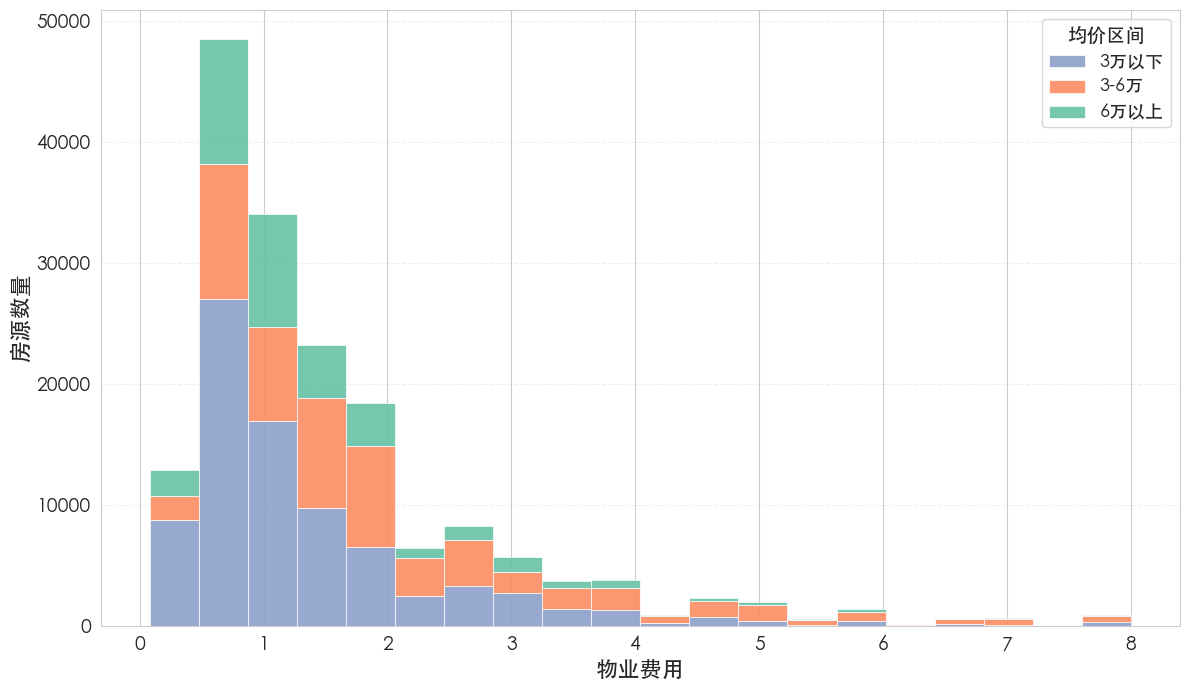

In [110]:
plot_histogram_n(df, "物业费用")

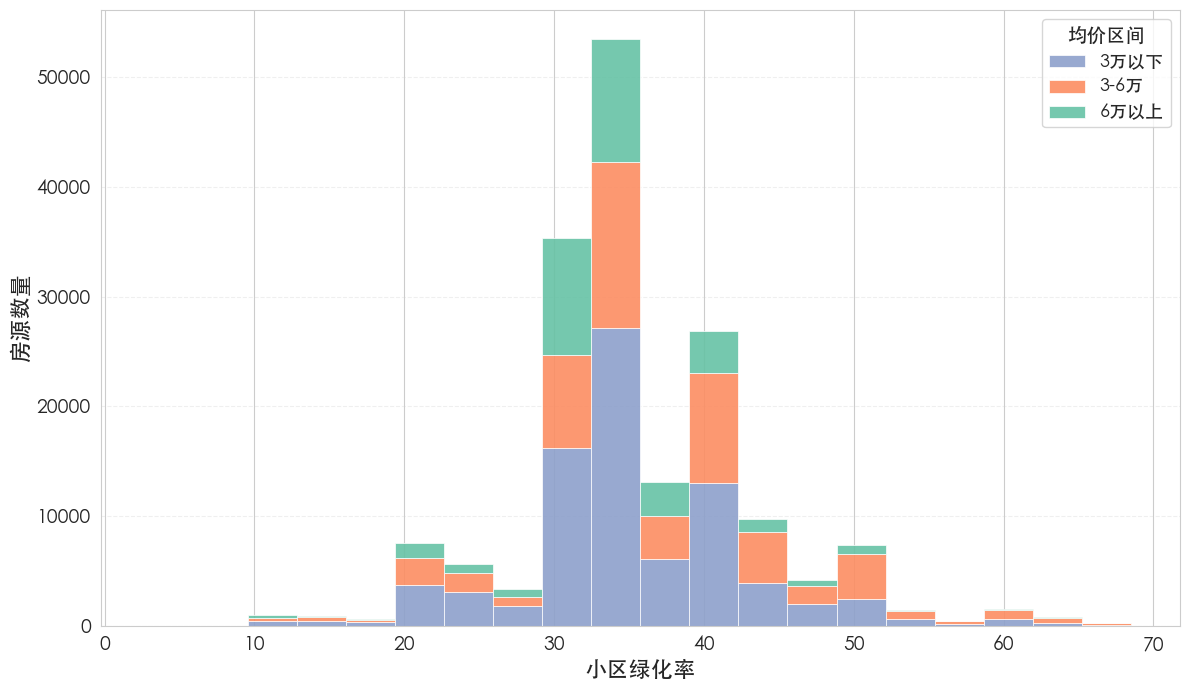

In [111]:
plot_histogram_n(df, "小区绿化率")

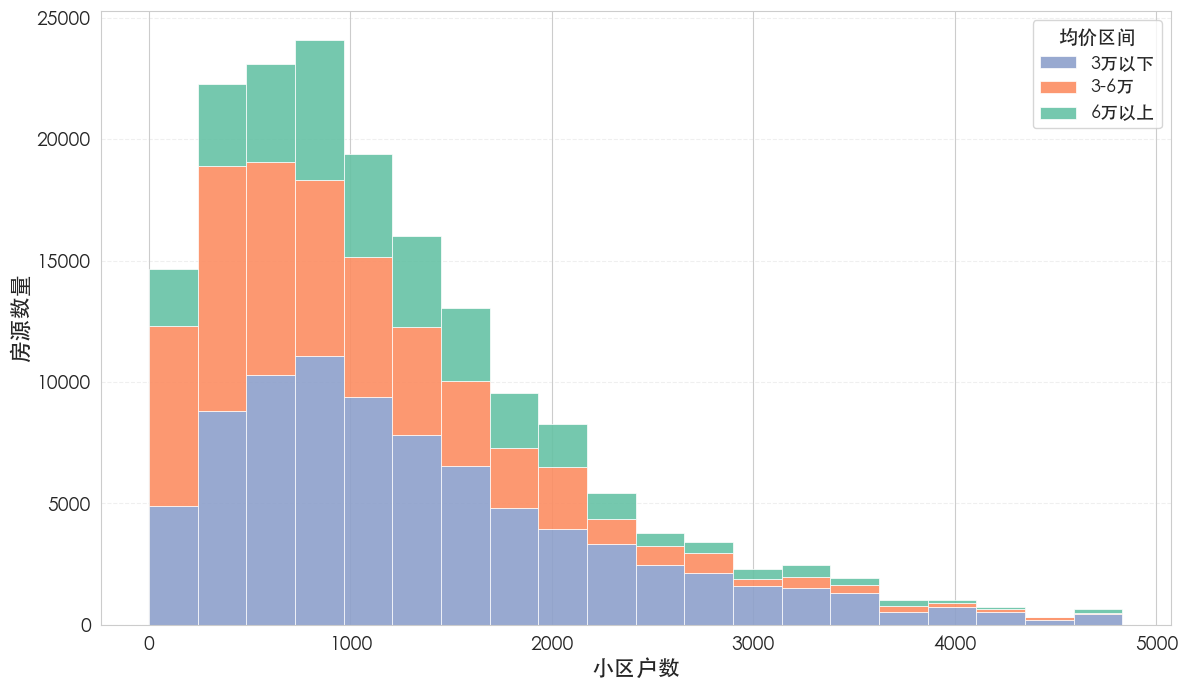

In [112]:
plot_histogram_n(df, "小区户数")

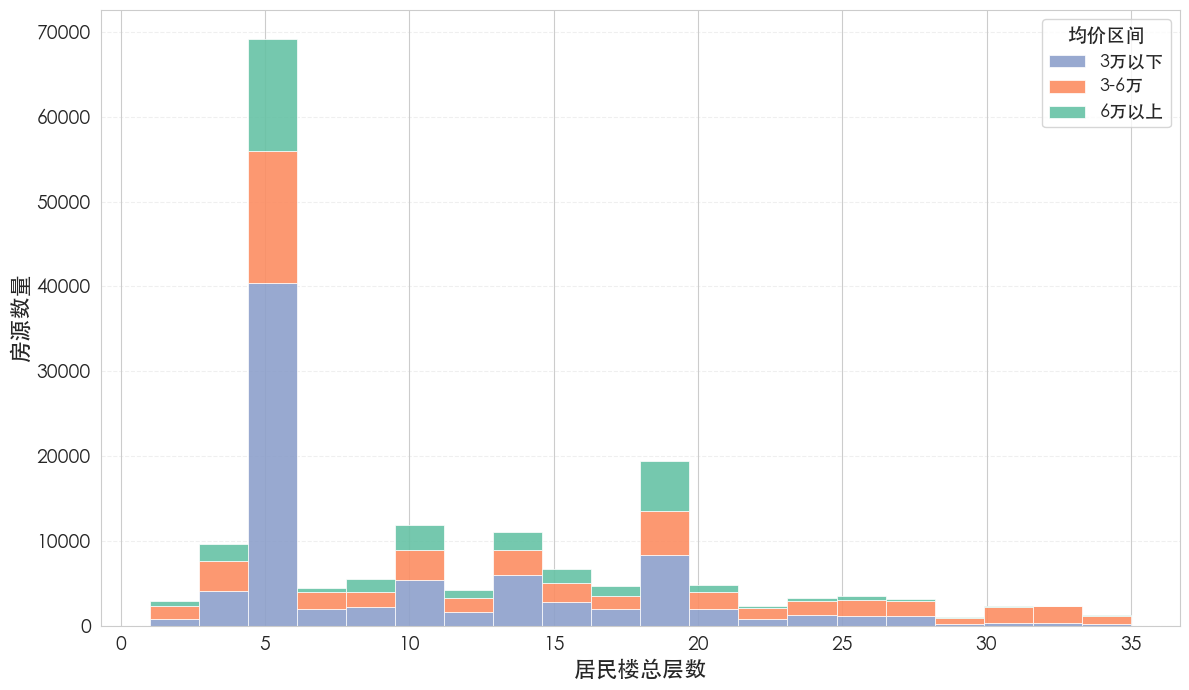

In [113]:
plot_histogram_n(df, "居民楼总层数")

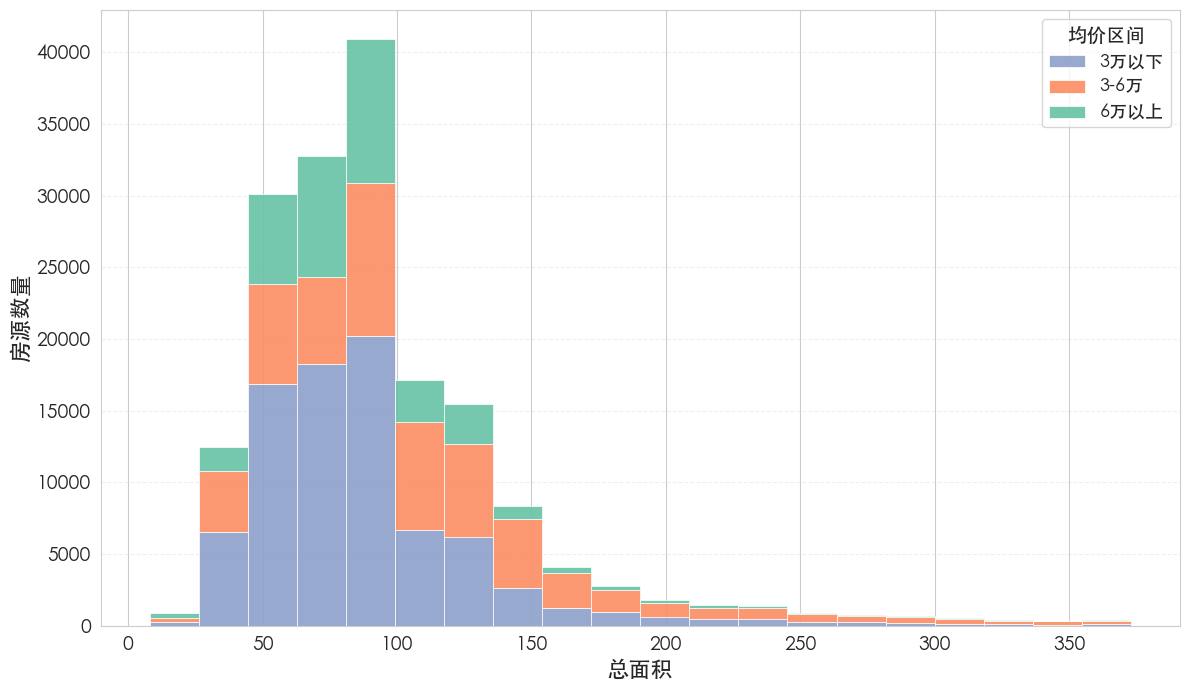

In [114]:
plot_histogram_n(df, "总面积")

In [116]:
df['总面积分组'] = df['总面积'].apply(
    lambda x: 
    '70平及以下' if x <= 70 else
    '70-100平' if x <= 100 else
    '100-150平' if x <= 150 else
    '150平以上'
)
stats = df.groupby('总面积分组')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

          count  mean  median   std
总面积分组                              
100-150平  38474  5.99    5.68  2.99
150平以上    17989  7.73    6.86  4.58
70-100平   62114  4.66    4.18  2.39
70平及以下    56550  4.91    4.77  2.26


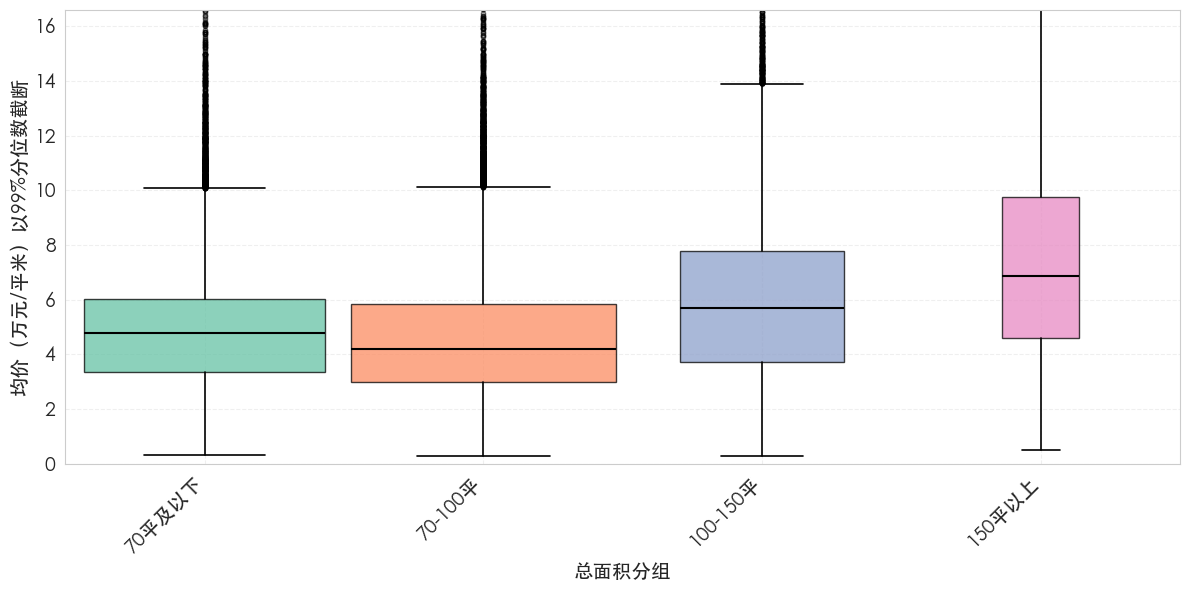


【总面积分组 统计】
          count  mean  median   std
总面积分组                              
100-150平  38474  5.99    5.68  2.99
150平以上    17989  7.73    6.86  4.58
70-100平   62114  4.66    4.18  2.39
70平及以下    56550  4.91    4.77  2.26

箱体宽度：
  70平及以下: 样本量=56550, 宽度=0.86
  70-100平: 样本量=62114, 宽度=0.95
  100-150平: 样本量=38474, 宽度=0.59
  150平以上: 样本量=17989, 宽度=0.28


In [117]:
plot_boxplot_single(df, '总面积分组',order=['70平及以下', '70-100平', '100-150平', '150平以上'])

In [118]:
df['物业费用分组'] = df['物业费用'].apply(
    lambda x: 
    '0.75及以下' if x <= 0.75 else
    '0.75-1.2' if x <= 1.2 else
    '1.2-2' if x <= 2 else
    '2以上'
)
stats = df.groupby('物业费用分组')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

          count  mean  median   std
物业费用分组                             
0.75-1.2  49082  4.66    4.23  2.46
0.75及以下   43944  4.66    4.62  1.96
1.2-2     43585  5.58    5.30  2.78
2以上       38516  6.75    5.89  3.94


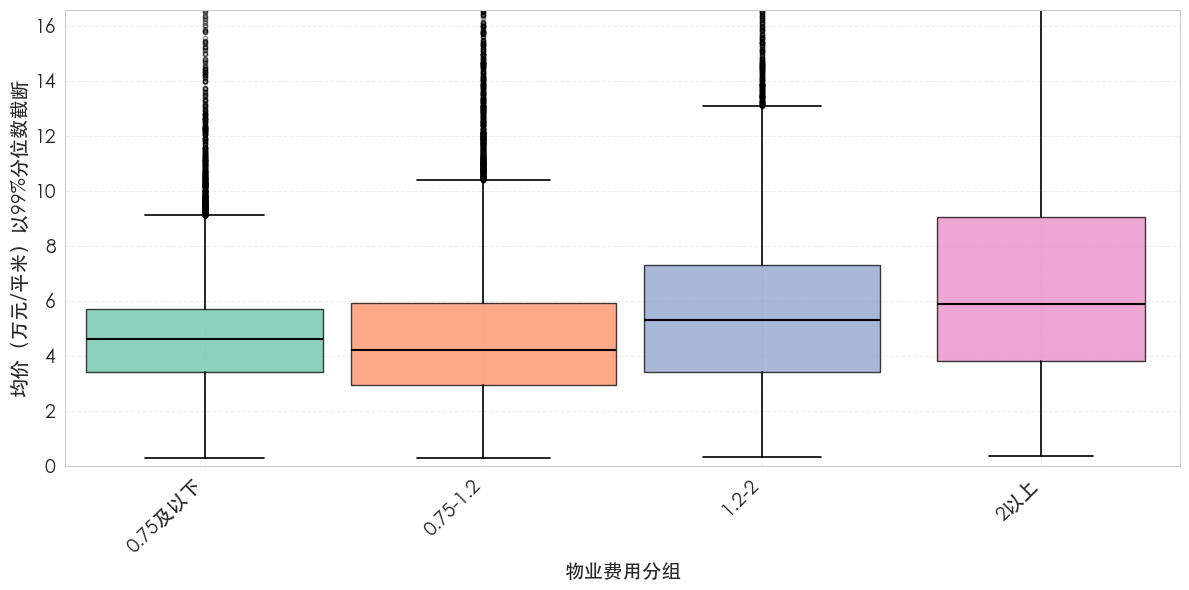


【物业费用分组 统计】
          count  mean  median   std
物业费用分组                             
0.75-1.2  49082  4.66    4.23  2.46
0.75及以下   43944  4.66    4.62  1.96
1.2-2     43585  5.58    5.30  2.78
2以上       38516  6.75    5.89  3.94

箱体宽度：
  0.75及以下: 样本量=43944, 宽度=0.85
  0.75-1.2: 样本量=49082, 宽度=0.95
  1.2-2: 样本量=43585, 宽度=0.84
  2以上: 样本量=38516, 宽度=0.75


In [119]:
plot_boxplot_single(df, '物业费用分组',order=['0.75及以下', '0.75-1.2', '1.2-2', '2以上'])

In [120]:
df['小区绿化率分组'] = df['小区绿化率'].apply(
    lambda x: 
    '30以下' if x <= 30 else
    '30-35' if x <= 35 else
    '35-40' if x <= 40 else
    '40以上'
)
stats = df.groupby('小区绿化率分组')['均价'].agg(['count', 'mean', 'median', 'std']).round(2)
print(stats)

         count  mean  median   std
小区绿化率分组                           
30-35    54686  5.22    4.58  3.02
30以下     51046  4.84    4.63  2.59
35-40    37558  5.38    4.84  2.81
40以上     31837  6.36    5.87  3.26


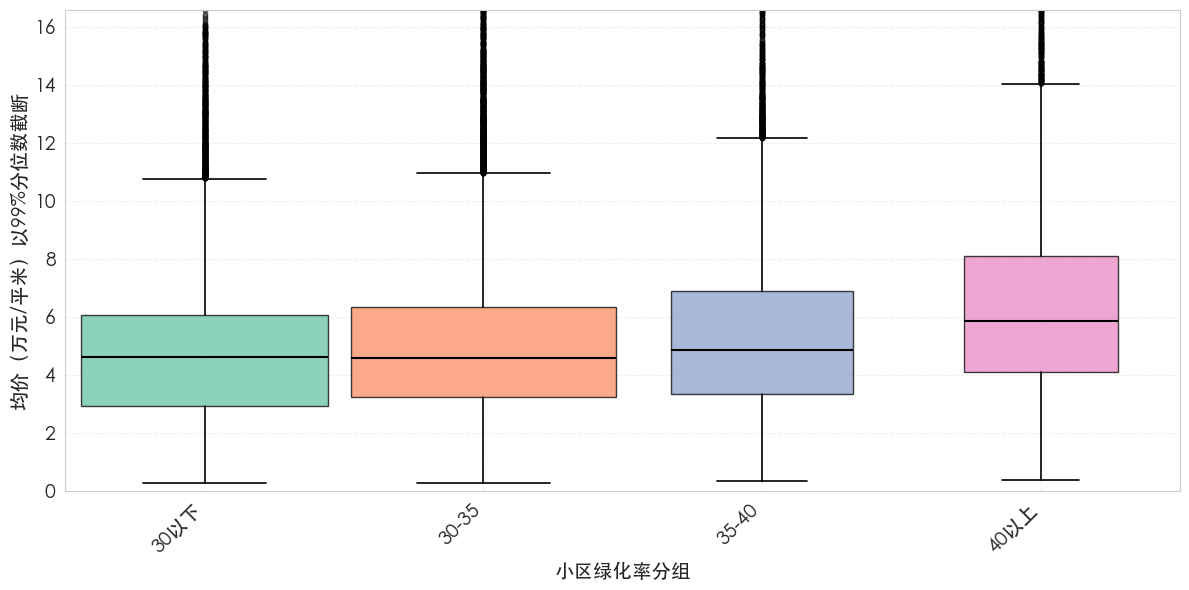


【小区绿化率分组 统计】
         count  mean  median   std
小区绿化率分组                           
30-35    54686  5.22    4.58  3.02
30以下     51046  4.84    4.63  2.59
35-40    37558  5.38    4.84  2.81
40以上     31837  6.36    5.87  3.26

箱体宽度：
  30以下: 样本量=51046, 宽度=0.89
  30-35: 样本量=54686, 宽度=0.95
  35-40: 样本量=37558, 宽度=0.65
  40以上: 样本量=31837, 宽度=0.55


In [121]:
plot_boxplot_single(df, '小区绿化率分组',order=['30以下', '30-35', '35-40', '40以上'])

📊 变量：装修
          频数  占比(%)
装修                 
精装修   133902  76.46
简单装修   25490  14.56
毛坯     12291   7.02
豪华装修    3444   1.97




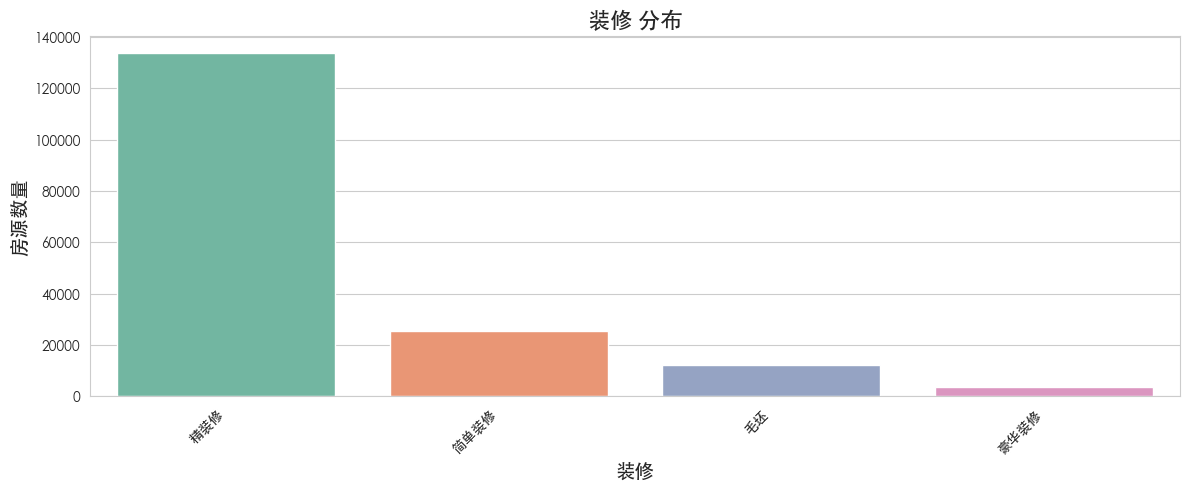

📊 变量：楼层分布
         频数  占比(%)
楼层分布              
中层    57776  32.99
高层    53934  30.80
低层    42699  24.38
未知    12652   7.22
全层     7569   4.32
地下      497   0.28




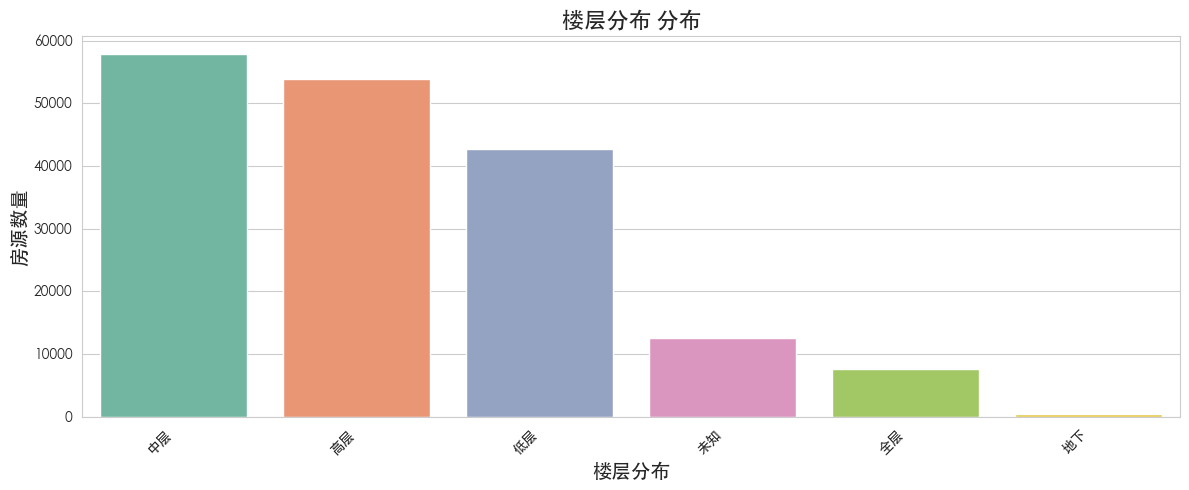

📊 变量：物业类型
          频数  占比(%)
物业类型               
普通住宅  160584  91.70
别墅      8187   4.67
公寓      5202   2.97
商住楼      463   0.26
新里洋房     392   0.22
其他       171   0.10
老公房       97   0.06
平房        31   0.02




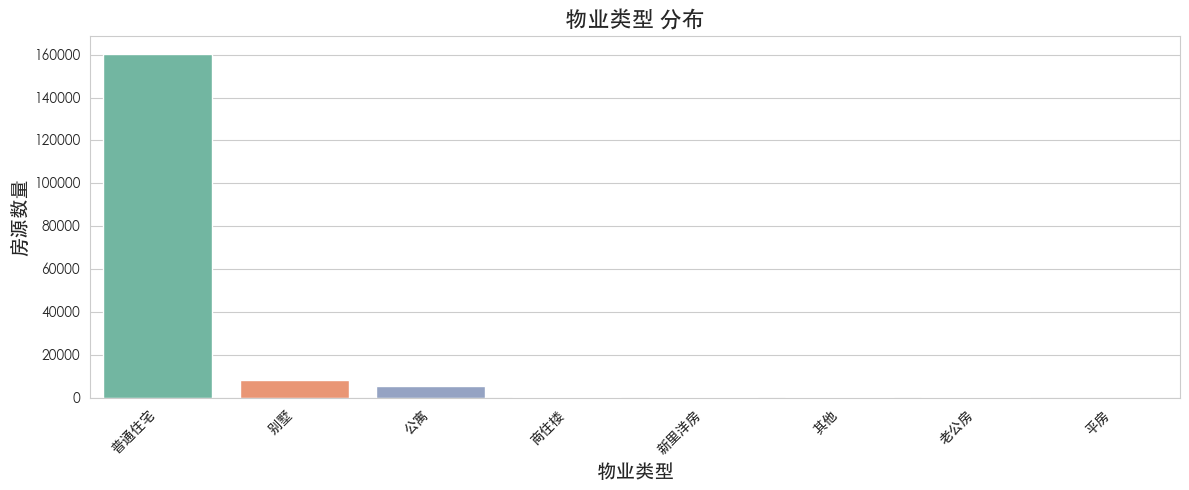

📊 变量：产权性质
           频数  占比(%)
产权性质                
商品房住宅  159251  90.93
其它       5968   3.41
动迁配套房    5926   3.38
商住两用     3662   2.09
经济适用房     175   0.10
公房        144   0.08
使用权         1   0.00




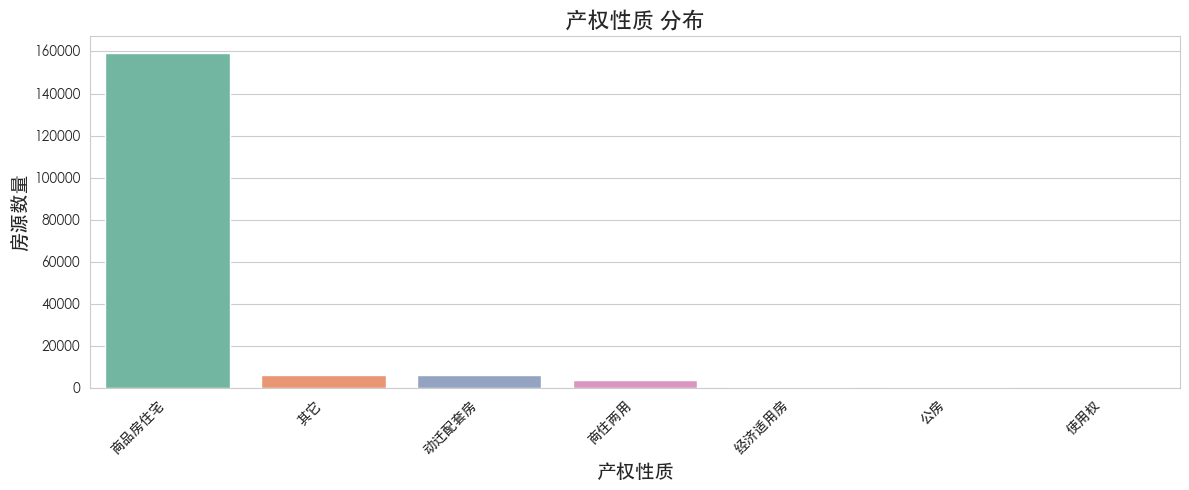

📊 变量：产权年限
           频数  占比(%)
产权年限                
70年产权  133650  76.32
未知      37504  21.42
50年产权    3551   2.03
40年产权     422   0.24




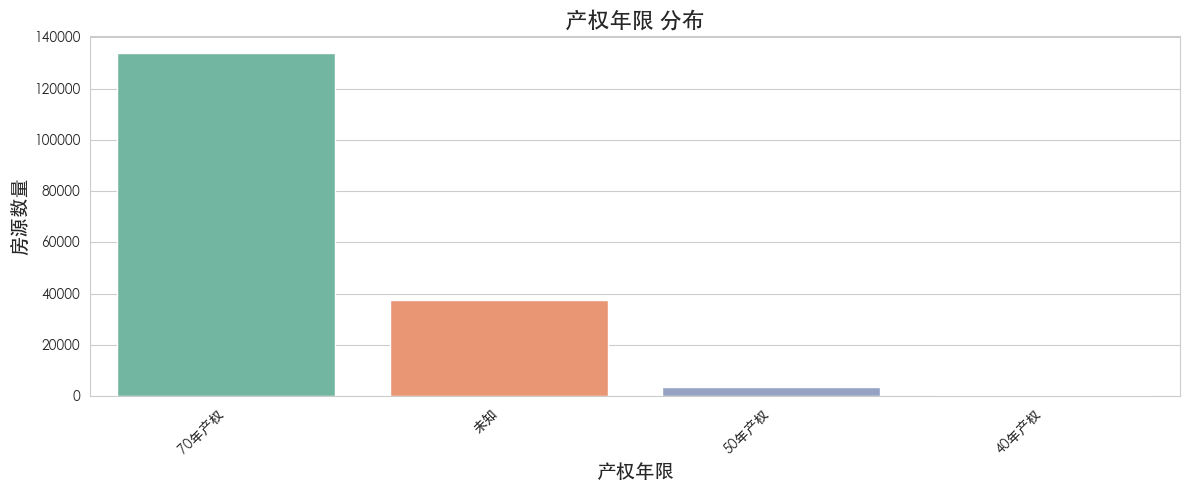

📊 变量：房本年限
          频数  占比(%)
房本年限               
满五年   137892  78.74
未知     30444  17.38
满二年     6791   3.88




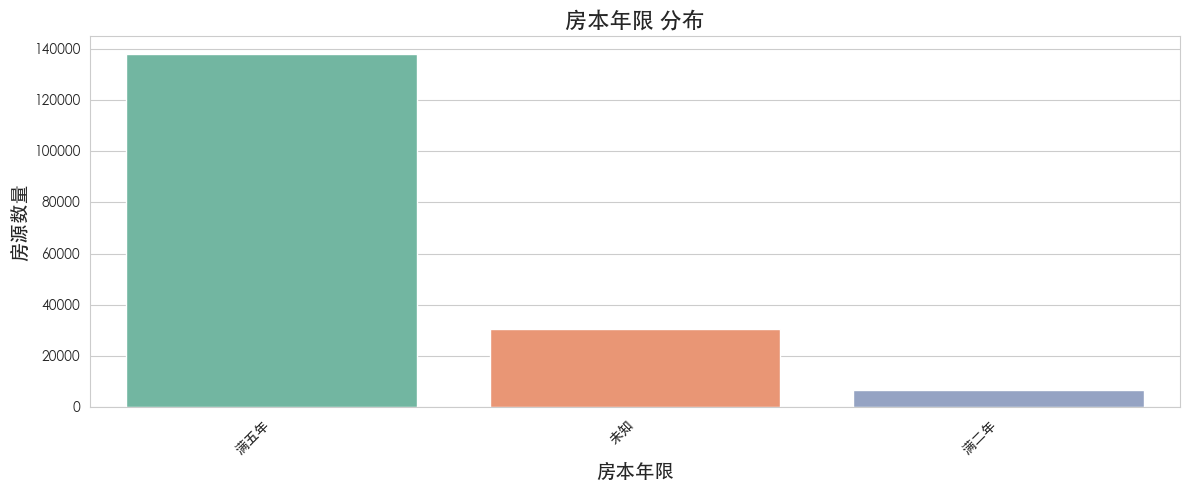

📊 变量：区
         频数  占比(%)
区                 
浦东    40970  23.39
闵行    21946  12.53
宝山    15273   8.72
松江    13897   7.94
嘉定    12798   7.31
徐汇    10326   5.90
普陀     9977   5.70
青浦     8177   4.67
奉贤     7107   4.06
静安     6990   3.99
长宁     6238   3.56
杨浦     6053   3.46
虹口     4777   2.73
黄浦     4055   2.32
金山     4024   2.30
上海周边   1297   0.74
崇明     1222   0.70




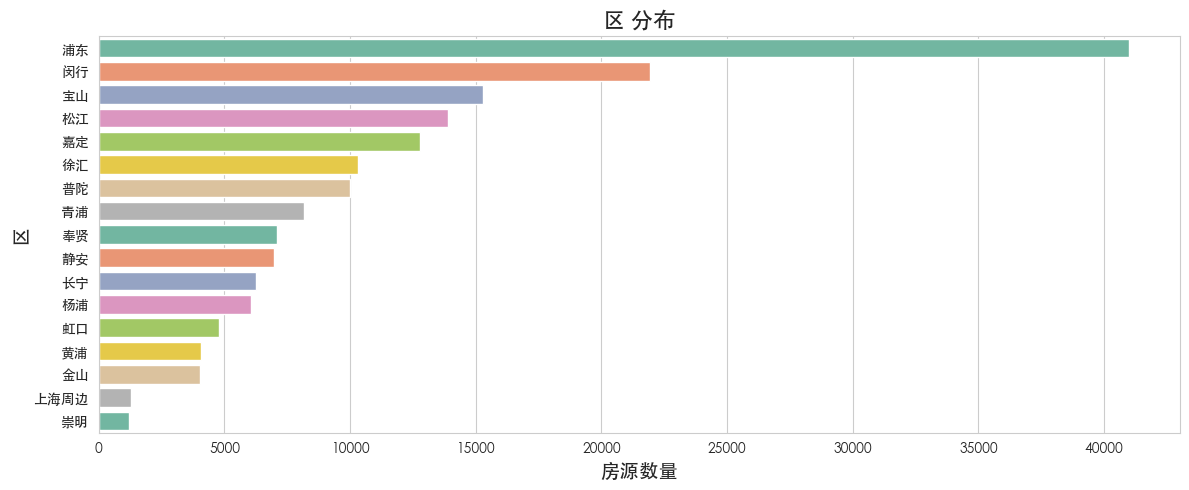

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== 中文显示设置 ====================
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 函数：查看字符型变量分布 ====================
def describe_categorical_vars(df):
    """
    自动识别并展示数据集中 字符型/分类变量 的分布
    1. 输出频数 + 占比
    2. 自动绘制分布图
    """
    # 你数据里的【分类字符变量】（排除唯一值太多的标题/街道/小区）
    cat_cols = [
        '装修', '楼层分布', '物业类型', 
        '产权性质', '产权年限', '房本年限', '区'
    ]
    
    # 遍历每个分类变量
    for col in cat_cols:
        if col not in df.columns:
            continue
            
        print(f"=" * 60)
        print(f"📊 变量：{col}")
        print(f"=" * 60)
        
        # 统计频数 + 占比
        val_counts = df[col].value_counts()
        val_pct = df[col].value_counts(normalize=True).mul(100).round(2)
        
        # 合并展示
        dist_df = pd.DataFrame({
            '频数': val_counts,
            '占比(%)': val_pct
        })
        print(dist_df)
        print("\n")
        
        # ==================== 绘图 ====================
        plt.figure(figsize=(12, 5))
        
        # 行政区单独横向展示（避免文字重叠）
        if col == '区':
            sns.barplot(y=dist_df.index, x=dist_df['频数'], palette='Set2')
            plt.xlabel('房源数量', fontsize=14, fontweight='bold')
            plt.ylabel(col, fontsize=14, fontweight='bold')
        else:
            sns.barplot(x=dist_df.index, y=dist_df['频数'], palette='Set2')
            plt.xlabel(col, fontsize=14, fontweight='bold')
            plt.ylabel('房源数量', fontsize=14, fontweight='bold')
            plt.xticks(rotation=45, ha='right')
        
        plt.title(f'{col} 分布', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

# ==================== 调用函数 ====================
describe_categorical_vars(df)

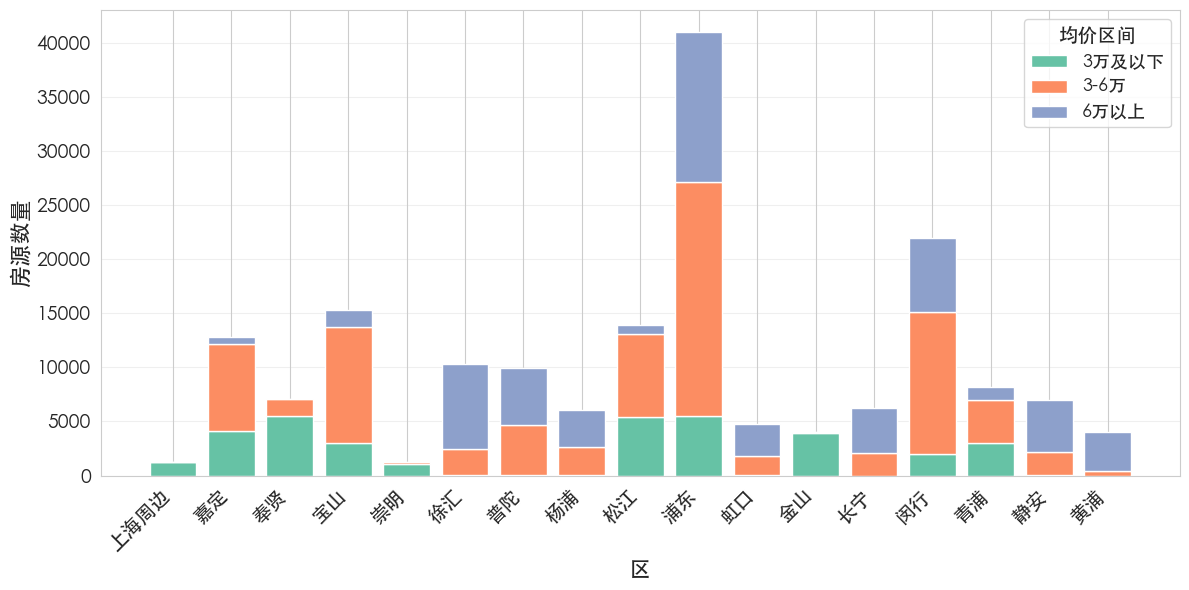

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== 中文显示配置 ====================
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 【核心函数】分类变量柱状图 + 按均价分组填充 ====================
def plot_cat_bar_by_price(df, cat_col):

    # 1. 计算交叉表（分类变量 × 均价分组）
    cross_tab = pd.crosstab(df[cat_col], df["均价分组"])

    cross_tab = cross_tab[["3万及以下", "3-6万", "6万以上"]]
    
    # 2. 绘图设置
    colors = ["#66c2a5", "#fc8d62", "#8da0cb"]  # 绿、橙、蓝
    x = np.arange(len(cross_tab.index))
    width = 0.8

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 3. 堆叠绘制柱状图
    bottom = np.zeros(len(cross_tab))
    for i, col in enumerate(cross_tab.columns):
        ax.bar(
            x, cross_tab[col], width, 
            label=col, color=colors[i], 
            bottom=bottom, edgecolor="white"
        )
        bottom += cross_tab[col]

    # 4. 样式&字体
    #ax.set_title(f'{cat_col} 分布（按均价区间分段）', fontsize=18, fontweight='bold')
    ax.set_xlabel(cat_col, fontsize=16, fontweight='bold')
    ax.set_ylabel('房源数量', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cross_tab.index, fontsize=14, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=14)
    
    # 图例
    ax.legend(title="均价区间", fontsize=13, title_fontsize=14, loc="upper right")
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'bar_{cat_col}_均价分组.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# ==================== 调用示例（直接运行） ====================
plot_cat_bar_by_price(df, "区")

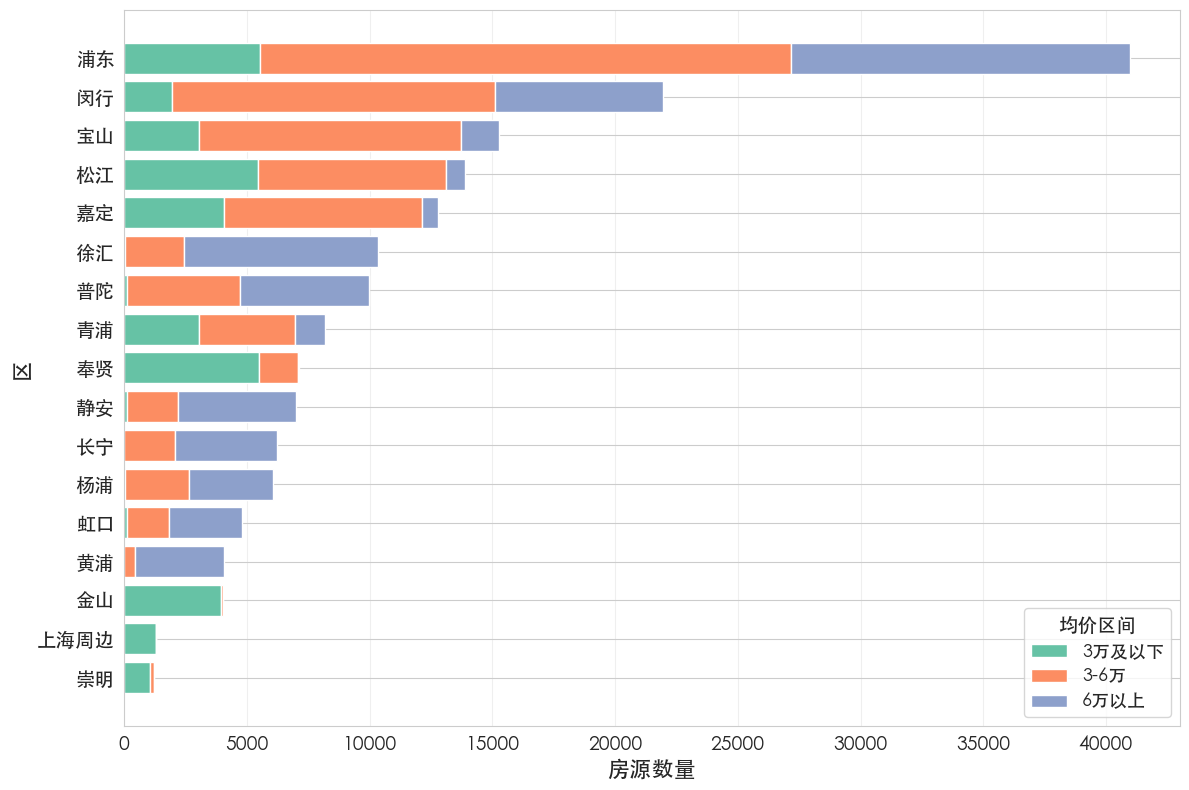

In [128]:


plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 【核心函数】横向排序+堆叠柱状图 ====================
def plot_cat_bar_by_price1(df, cat_col):

    # 1. 计算交叉表（分类变量 × 均价分组）
    cross_tab = pd.crosstab(df[cat_col], df["均价分组"])
    # 匹配你的分组名称
    cross_tab = cross_tab[["3万及以下", "3-6万", "6万以上"]]
    
    # 🔥 新增：按总频数降序排序（从上到下数量从多到少）
    cross_tab['总计'] = cross_tab.sum(axis=1)
    # 横向图固定 ascending=True，实现从上到下递减
    cross_tab = cross_tab.sort_values('总计', ascending=True)
    cross_tab = cross_tab.drop('总计', axis=1)

    # 2. 绘图设置（改为横向）
    colors = ["#66c2a5", "#fc8d62", "#8da0cb"]
    y = np.arange(len(cross_tab.index))  # 横向用y轴
    height = 0.8  # 柱子高度

    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 3. 横向堆叠柱状图（核心修改：bar → barh）
    left = np.zeros(len(cross_tab))
    for i, col in enumerate(cross_tab.columns):
        ax.barh(
            y, cross_tab[col], height,
            label=col, color=colors[i],
            left=left, edgecolor="white"
        )
        left += cross_tab[col]

    # 4. 样式&字体（适配横向图表）
    ax.set_xlabel('房源数量', fontsize=16, fontweight='bold')
    ax.set_ylabel(cat_col, fontsize=16, fontweight='bold')
    
    # 横向图表刻度设置
    ax.set_yticks(y)
    ax.set_yticklabels(cross_tab.index, fontsize=14)
    ax.tick_params(axis='x', labelsize=14)
    
    # 图例
    ax.legend(title="均价区间", fontsize=13, title_fontsize=14, loc="lower right")
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'bar_{cat_col}_均价分组.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# ==================== 调用示例 ====================
plot_cat_bar_by_price1(df, "区")

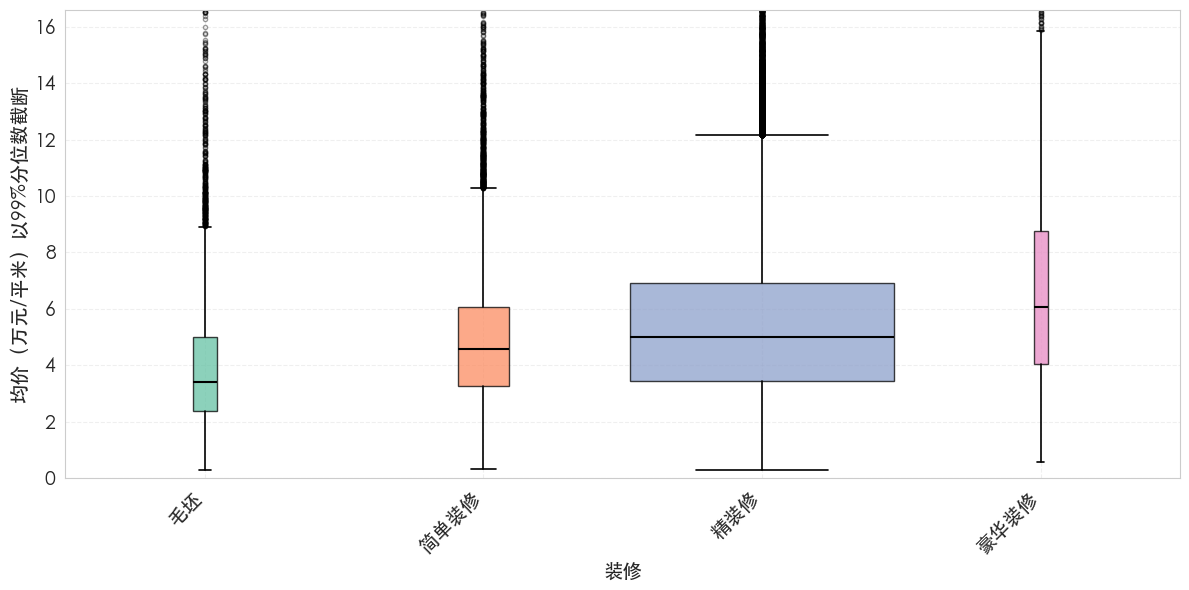


【装修 统计】
       count  mean  median   std
装修                              
毛坯     12291  4.01    3.43  2.46
简单装修   25490  4.93    4.57  2.47
精装修   133902  5.51    5.00  2.98
豪华装修    3444  7.03    6.07  4.44

箱体宽度：
  毛坯: 样本量=12291, 宽度=0.09
  简单装修: 样本量=25490, 宽度=0.18
  精装修: 样本量=133902, 宽度=0.95
  豪华装修: 样本量=3444, 宽度=0.05


In [130]:
plot_boxplot_single(df, '装修',order=['毛坯', '简单装修', '精装修', '豪华装修'])

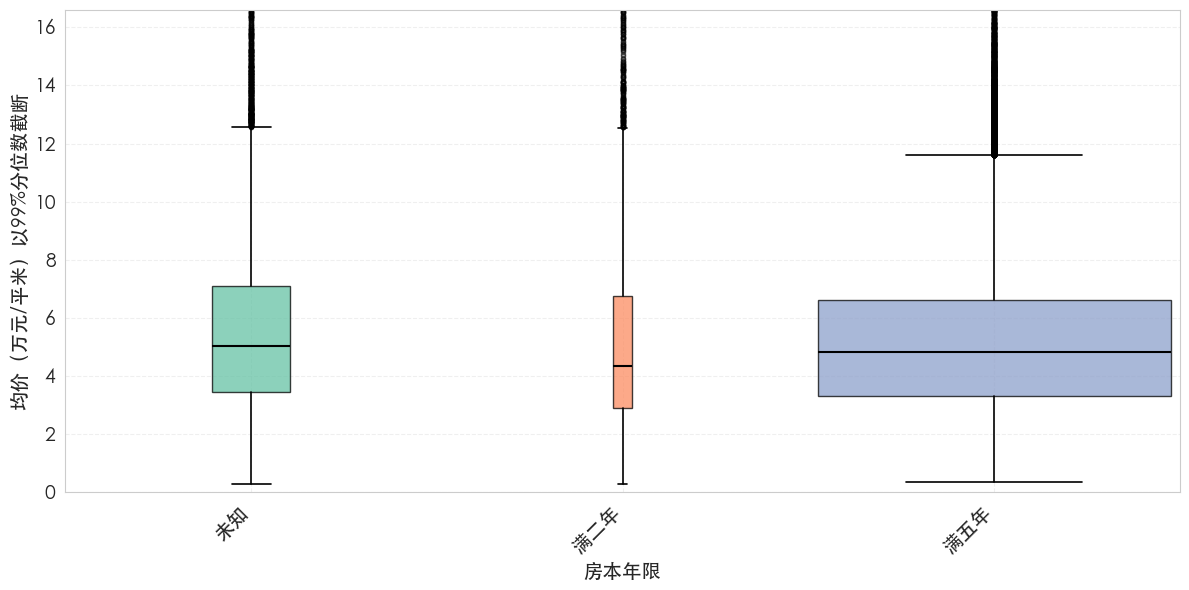


【房本年限 统计】
       count  mean  median   std
房本年限                            
未知     30444  5.65    5.04  3.21
满二年     6791  5.56    4.34  4.07
满五年   137892  5.27    4.81  2.82

箱体宽度：
  未知: 样本量=30444, 宽度=0.21
  满二年: 样本量=6791, 宽度=0.05
  满五年: 样本量=137892, 宽度=0.95


In [131]:
plot_boxplot_single(df, '房本年限',order=['未知', '满二年', '满五年'])

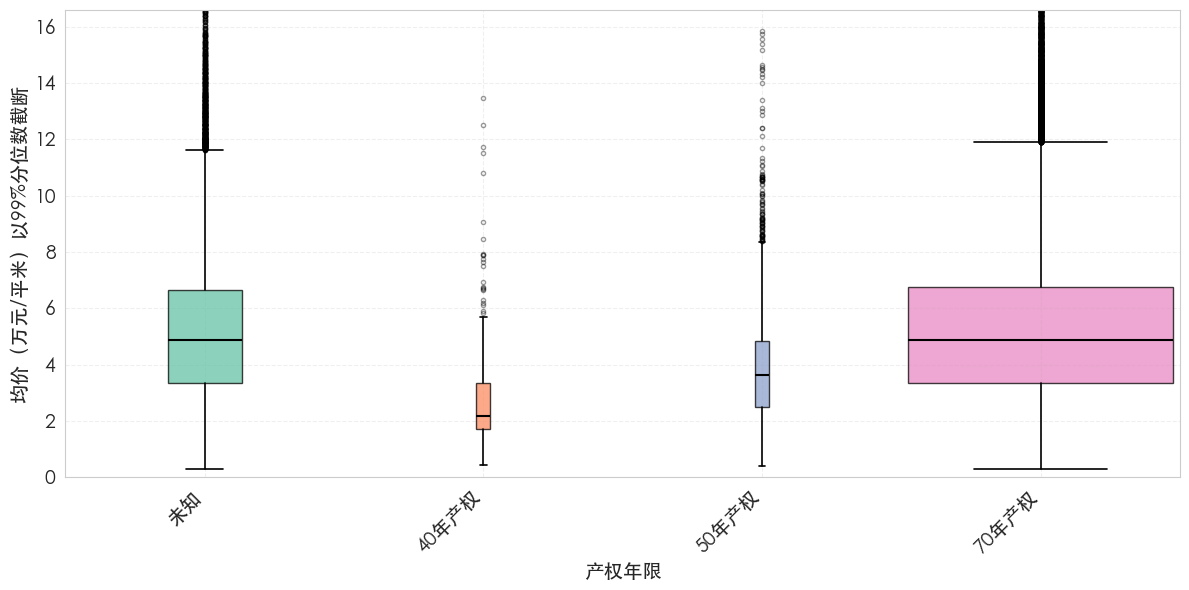


【产权年限 统计】
        count  mean  median   std
产权年限                             
40年产权     422  2.83    2.17  2.13
50年产权    3551  3.93    3.65  2.07
70年产权  133650  5.41    4.88  3.00
未知      37504  5.29    4.87  2.79

箱体宽度：
  未知: 样本量=37504, 宽度=0.27
  40年产权: 样本量=422, 宽度=0.05
  50年产权: 样本量=3551, 宽度=0.05
  70年产权: 样本量=133650, 宽度=0.95


In [132]:
plot_boxplot_single(df, '产权年限',order=['未知', '40年产权', '50年产权', '70年产权'])

In [23]:
# 使用清华镜像源安装
!pip install warnings -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
ERROR: Could not find a version that satisfies the requirement warnings (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for warnings
